# Error Analysis & Error Tracing

This notebook traces model errors across domains, conditions, and models.  
Key questions:

1. **What types of errors do models make?** (magnitude errors, decimal shifts, refusals, hallucinated values, rounding)
2. **Math-only vs No-guide:** When the model can do the arithmetic, but fails the domain-phrased version — why?
3. **Cross-domain consistency:** Same input number, correct in one domain, wrong in another — what drives the difference?
4. **Reasoning vs Non-reasoning:** Do error profiles differ between model types?

This notebook can be used to load in either the full results or only integer values.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
import re
import scienceplots
warnings.filterwarnings('ignore', category=FutureWarning)

# ── Publication style ────────────────────────────────────────────
plt.style.use(['science', 'ieee'])
sns.set_style("whitegrid")

COL_W = 3.5       # single journal column (inches)
PAGE_W = 7.2      # full page width
GOLDEN = 1.618

FIGURES_DIR = Path('/data/jane/convert/math_gender/conversion_test/3_error_taxonomy/figures')
FIGURES_DIR.mkdir(exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'legend.title_fontsize': 8,
    'axes.linewidth': 0.6,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.4,
    'lines.linewidth': 1.0,
    'lines.markersize': 4,
})

def save_fig(fig, name):
    """Save figure as PDF + PNG to figures dir."""
    fig.savefig(FIGURES_DIR / f'{name}.pdf')
    fig.savefig(FIGURES_DIR / f'{name}.png', dpi=300)
    print(f'  → saved {name}.pdf / .png')

# ── Colorblind-safe palette (Paul Tol qualitative) ──────────────
CB_PALETTE = ['#332288', '#88CCEE', '#44AA99', '#117733', '#999933',
              '#DDCC77', '#CC6677', '#882255', '#AA4499', '#661100']

# ── Model & condition config ────────────────────────────────────
NON_REASONING_MODELS = ['gpt-4o', 'qwen-coder', 'llama-4', 'gpt-oss-120b']
REASONING_MODELS = ['gpt-5.2', 'deepseek-v3.1', 'claude-haiku-4-5', 'qwen3-235b-thinking']
ALL_MODELS = NON_REASONING_MODELS + REASONING_MODELS

CONDITIONS = {
    'in_domain_with_guide': 'results',
    'in_domain_no_guide': 'results_no_guide',
    'math_only': 'results_math_only',
}

MODEL_DISPLAY = {
    'gpt-4o': 'GPT-4o',
    'qwen-coder': 'Qwen3-Coder',
    'llama-4': 'Llama-4-Maverick',
    'gpt-5.2': 'GPT-5.2',
    'deepseek-v3.1': 'DeepSeek-V3.1',
    'qwen3-235b-thinking': 'Qwen3-235B',
    'claude-haiku-4-5': 'Claude-Haiku-4.5',
    'gpt-oss-120b': 'GPT-OSS-120B',
}

REASONING_MARKER = {m: ' ★' if m in REASONING_MODELS else '' for m in ALL_MODELS}

MODEL_COLORS = {m: CB_PALETTE[i % len(CB_PALETTE)] for i, m in enumerate(ALL_MODELS)}

CONDITION_DISPLAY = {
    'in_domain_with_guide': 'With Guide',
    'in_domain_no_guide': 'No Guide',
    'math_only': 'Math Only',
}

HATCHES = ['///', '...', 'xxx', '\\\\\\', '---', 'ooo', '+++', '***', 'OOO', '']

print(f"Models: {ALL_MODELS}")
print(f"Conditions: {list(CONDITIONS.keys())}")
print(f"Figures dir: {FIGURES_DIR}")

Models: ['gpt-4o', 'qwen-coder', 'llama-4', 'gpt-oss-120b', 'gpt-5.2', 'deepseek-v3.1', 'claude-haiku-4-5', 'qwen3-235b-thinking']
Conditions: ['in_domain_with_guide', 'in_domain_no_guide', 'math_only']


## 1. Load All Results

In [2]:
df = pd.read_csv('/data/jane/convert/math_gender/conversion_test/2_analysis/integers.csv', sep='\t')
print(f"loaded {len(df):,} rows")
print(f"columns: {df.columns.tolist()}")
print(f"models: {df['model'].unique()}")
print(f"conditions: {df['condition'].unique()}")
print(f"domains: {df['domain'].unique()}")


/tmp/ipykernel_264986/753506507.py:1: DtypeWarning: Columns (1,3,4,7,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/data/jane/convert/math_gender/conversion_test/2_analysis/integers.csv', sep='\t')


loaded 1,986,888 rows
columns: ['domain', 'distractor', 'prompt', 'number', 'answer', 'difficulty', 'raw_response', 'model_answer', 'loss', 'reasoning_tokens', 'call_seconds', 'model', 'condition', 'frequency', 'frequency_level', 'is_reasoning', 'display_name', 'is_correct', 'num_decimals', 'num_input_decimals', 'frequency_difficulty']
models: ['claude-haiku-4-5' 'deepseek-v3.1' 'gpt-4o' 'gpt-5.2' 'gpt-oss-120b'
 'llama-4' 'qwen-coder' 'qwen3-235b-thinking']
conditions: ['in_domain_with_guide' 'math_only' 'in_domain_no_guide']
domains: ['bits_bytes' 'clothing_size' 'cooking' 'currency' 'density' 'energy'
 'moles_to_particles' 'speed' 'temperature' 'timezone' 'volume']


In [3]:
len(df)

1986888

## 2. Error Classification

Classify each wrong answer into an error type based on the relationship between the model's answer and the gold answer.

In [4]:
def classify_error(row):
    """Classify the error type for a single wrong row.
    
    Returns one of:
      'correct'           – loss == 0
      'refusal'           – no valid numeric answer AND refusal keywords in answer/response
      'degenerate_loop'   – model enters a repetitive loop (often ends in [TRUNCATED])
      'changed_answer'    – correct answer in reasoning trace but wrong answer in <answer> tags
      'rounding'          – loss <= 2 (small precision difference)
      'decimal_shift'     – answer differs by a power of 10
      'magnitude_error'   – answer is >100× or <0.01× the gold
      'extra_factor'      – model_answer divides gold or gold divides model_answer (integer ratio >= 2)
      'sign_error'        – correct absolute value, wrong sign
      'moderate_error'    – loss between 2 and 100 (not fitting above)
      'large_error'       – loss > 100
    """
    loss = row['loss']
    if pd.isna(loss) or loss == 0:
        return 'correct'
    
    # Refusal detection: no <answer> tags AND no [TRUNCATED] (truncated → degenerate_loop)
    _REFUSAL_KW = ['n/a', 'cannot', 'i cannot', 'unable to', 'not possible', 'impossible', 'i don\'t have realtime', 'don\'t have access', 'my knowledge was last updated', 'exchange rates fluctuate','real-time access','i apologize','have access']
    raw = str(row.get('raw_response', ''))
    if not re.search(r'<answer>', raw, re.IGNORECASE) and '[TRUNCATED]' not in raw:
        if any(kw in raw.lower() for kw in _REFUSAL_KW):
            return 'refusal'
    
    # Degenerate loop detection
    raw_text = str(row.get('raw_response', ''))
    has_truncated = '[TRUNCATED]' in raw_text
    clean_text = raw_text.replace('[TRUNCATED]', '').replace('[/REASONING]', '').replace('[REASONING]', '').strip()
    if has_truncated and len(clean_text) < 200:
        return 'degenerate_loop'
    if len(clean_text) >= 500:
        sample = clean_text[-3000:] if len(clean_text) > 3000 else clean_text
        _chunk = 50
        chunks = [sample[i:i+_chunk] for i in range(0, len(sample) - _chunk + 1, _chunk)]
        if len(chunks) >= 6:
            unique_ratio = len(set(chunks)) / len(chunks)
            if unique_ratio < (0.3 if has_truncated else 0.15):
                return 'degenerate_loop'
    
    # Changed answer: correct value in reasoning but wrong value in <answer> tags
    raw = str(row.get('raw_response', ''))
    answer_tags = re.findall(r'<answer>(.*?)</answer>', raw, re.IGNORECASE | re.DOTALL)
    if answer_tags:
        gold_str = str(row['answer'])
        try:
            gold_val = float(gold_str)
            # Build reasoning text: everything outside the last <answer> tag
            last_tag_start = raw.rfind('<answer>')
            reasoning = raw[:last_tag_start] if last_tag_start > 0 else ''
            # Check if gold value appears in the reasoning (as a number)
            reasoning_nums = re.findall(r'-?\d+\.?\d*', reasoning)
            for n in reasoning_nums:
                try:
                    if gold_val != 0 and abs(float(n) - gold_val) / abs(gold_val) < 0.005:
                        return 'changed_answer'
                except ValueError:
                    continue
        except (ValueError, TypeError):
            pass
    
    if loss <= 2:
        return 'rounding'
    
    try:
        gold = float(row['answer'])
        model_ans = float(row.get('model_answer', np.nan))
        if pd.isna(model_ans) or gold == 0:
            if loss > 100:
                return 'large_error'
            return 'moderate_error'
        
        ratio = model_ans / gold if gold != 0 else float('inf')
        abs_ratio = abs(ratio)
        
        if abs(gold) > 0 and model_ans < 0 and gold > 0 or model_ans > 0 and gold < 0:
            if abs(abs(model_ans) - abs(gold)) / abs(gold) < 0.05:
                return 'sign_error'
        
        for power in range(-6, 7):
            if power == 0:
                continue
            expected_ratio = 10 ** power
            if 0.9 < abs_ratio / expected_ratio < 1.1:
                return 'decimal_shift'
        
        if abs_ratio > 100 or abs_ratio < 0.01:
            return 'magnitude_error'
        
        if model_ans != 0:
            g_over_m = gold / model_ans
            m_over_g = model_ans / gold
            if (abs(g_over_m - round(g_over_m)) < 0.05 and abs(round(g_over_m)) >= 2) or \
               (abs(m_over_g - round(m_over_g)) < 0.05 and abs(round(m_over_g)) >= 2):
                return 'extra_factor'
    except (ValueError, TypeError, ZeroDivisionError):
        pass
    
    if loss > 100:
        return 'large_error'
    return 'moderate_error'


df['error_type'] = df.apply(classify_error, axis=1)

print("Error type distribution (all data):")
print(df['error_type'].value_counts().to_string())
print(f"\nTotal correct: {(df['error_type']=='correct').sum():,} / {len(df):,} ({(df['error_type']=='correct').mean()*100:.1f}%)")

Error type distribution (all data):
error_type
correct            1664723
moderate_error       89166
rounding             65786
decimal_shift        62135
changed_answer       33532
magnitude_error      30039
large_error          24991
extra_factor         13952
refusal               2368
degenerate_loop        191
sign_error               5

Total correct: 1,664,723 / 1,986,888 (83.8%)


### 2.1 Error Type Distribution by Model

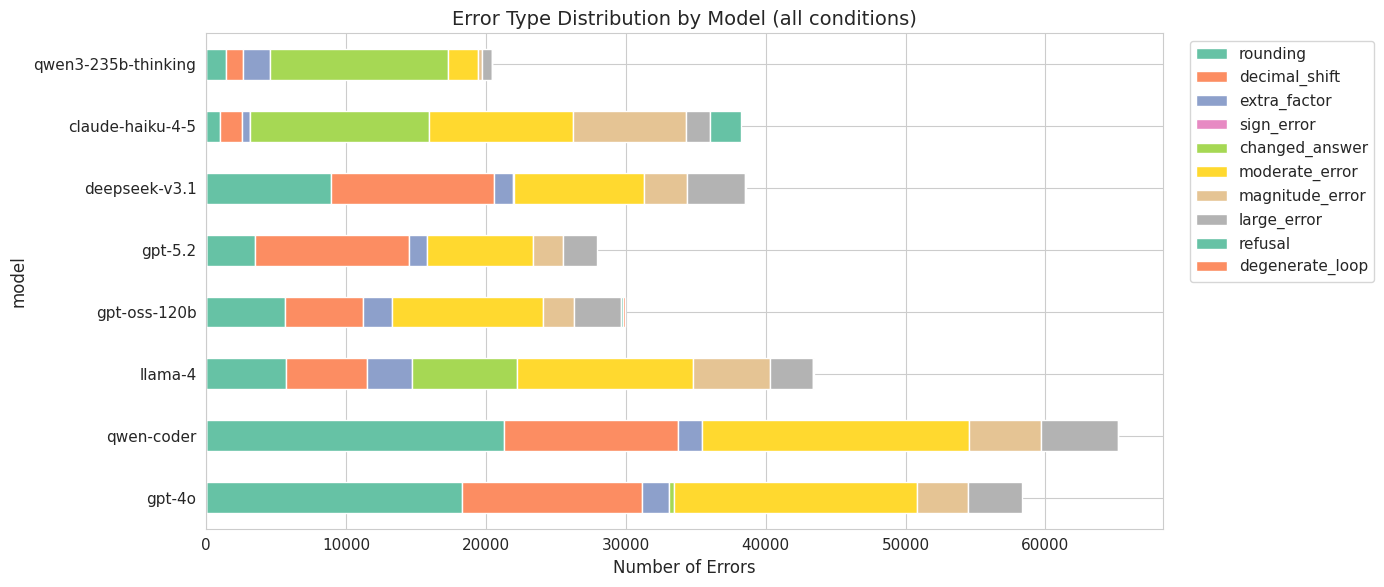


Error counts:
error_type           rounding  decimal_shift  extra_factor  sign_error  changed_answer  moderate_error  magnitude_error  large_error  refusal  degenerate_loop
model                                                                                                                                                         
gpt-4o                  18316          12856          1883           0             385           17348             3683         3838        0                0
qwen-coder              21298          12438          1729           0               0           19076             5123         5511        2                0
llama-4                  5697           5797          3192           0            7532           12566             5503         3131        2               13
gpt-oss-120b             5639           5541          2097           0               0           10839             2179         3391      113              174
gpt-5.2                  3511  

In [5]:
errors_only = df[df['error_type'] != 'correct'].copy()

ct = pd.crosstab(errors_only['model'], errors_only['error_type'])
ct = ct.reindex(index=[m for m in ALL_MODELS if m in ct.index])
error_order = ['rounding', 'decimal_shift', 'extra_factor', 'sign_error', 'changed_answer', 'moderate_error', 'magnitude_error', 'large_error', 'refusal', 'degenerate_loop']
ct = ct.reindex(columns=[c for c in error_order if c in ct.columns])

ERROR_COLORS = {e: CB_PALETTE[i % len(CB_PALETTE)] for i, e in enumerate(error_order)}
ERROR_HATCHES = {e: HATCHES[i % len(HATCHES)] for i, e in enumerate(error_order)}

fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN / 1.8))
labels = [MODEL_DISPLAY.get(m, m) + REASONING_MARKER.get(m, '') for m in ct.index]
y = np.arange(len(ct))
left = np.zeros(len(ct))
for col in ct.columns:
    vals = ct[col].values.astype(float)
    bars = ax.barh(y, vals, left=left, label=col, color=ERROR_COLORS[col],
                   hatch=ERROR_HATCHES[col], edgecolor='white', linewidth=0.4, height=0.7)
    left += vals
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('Number of Errors')
ax.set_title('Error Type Distribution by Model (All Conditions)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True,
          edgecolor='#cccccc', fancybox=False)
ax.invert_yaxis()
plt.tight_layout()
save_fig(fig, 'fig1_error_by_model')
plt.show()

In [6]:
# ── Publication-ready tables: Error type percentages ─────────────

# Table 1: Overall error type distribution
overall = errors_only['error_type'].value_counts()
overall_pct = (overall / overall.sum() * 100).round(1)
overall_df = pd.DataFrame({'Count': overall, '%': overall_pct})
overall_df = overall_df.reindex([c for c in error_order if c in overall_df.index])
overall_df.index.name = 'Error Type'

print("TABLE 1: Overall Error Type Distribution")
print(overall_df.to_string())
print(f"\nTotal errors: {overall.sum():,}")
print("\n--- LaTeX ---")
print(overall_df.to_latex(caption='Overall error type distribution.',
                          label='tab:error_overall', bold_rows=True))

# Table 2: Error type % by model (row-normalized)
ct_pct = pd.crosstab(errors_only['model'], errors_only['error_type'], normalize='index') * 100
ct_pct = ct_pct.reindex(index=[m for m in ALL_MODELS if m in ct_pct.index])
ct_pct = ct_pct.reindex(columns=[c for c in error_order if c in ct_pct.columns])
ct_pct['N'] = errors_only.groupby('model').size().reindex(ct_pct.index)
ct_pct.index = [MODEL_DISPLAY.get(m, m) + REASONING_MARKER.get(m, '') for m in ct_pct.index]
ct_pct.index.name = 'Model'

print("\n\nTABLE 2: Error Type % by Model (row-normalized)")
print(ct_pct.round(1).to_string())
print("\n--- LaTeX ---")
print(ct_pct.round(1).to_latex(caption='Error type distribution (\\%) by model. Each row sums to 100\\%.',
                                label='tab:error_by_model'))

# Table 3: Model share of total errors
model_share = errors_only['model'].value_counts()
model_share_pct = (model_share / model_share.sum() * 100).round(1)
model_share_df = pd.DataFrame({'N Errors': model_share, 'Share (%)': model_share_pct})
model_share_df = model_share_df.reindex([m for m in ALL_MODELS if m in model_share_df.index])
model_share_df.index = [MODEL_DISPLAY.get(m, m) + REASONING_MARKER.get(m, '') for m in model_share_df.index]
model_share_df.index.name = 'Model'

print("\n\nTABLE 3: Model Share of Total Errors")
print(model_share_df.to_string())
print("\n--- LaTeX ---")
print(model_share_df.to_latex(caption='Share of total errors by model.',
                               label='tab:error_model_share'))

=== Overall Error Type Distribution ===
                 count     %
error_type                  
rounding         65786  20.4
decimal_shift    62135  19.3
extra_factor     13952   4.3
sign_error           5   0.0
changed_answer   33532  10.4
moderate_error   89166  27.7
magnitude_error  30039   9.3
large_error      24991   7.8
refusal           2368   0.7
degenerate_loop    191   0.1

Total errors: 322,165


=== Error Type % by Model (row-normalized) ===
error_type           rounding  decimal_shift  extra_factor  sign_error  changed_answer  moderate_error  magnitude_error  large_error  refusal  degenerate_loop  n_errors
model                                                                                                                                                                   
gpt-4o                   31.4           22.0           3.2         0.0             0.7            29.8              6.3          6.6      0.0              0.0     58309
qwen-coder               32.7    

In [7]:
# Error type breakdown by CONDITION: overall and by model (%)

CONDITION_DISPLAY = {
    'math_only': 'Math Only',
    'in_domain_with_guide': 'In Domain with Guide',
    'in_domain_no_guide': 'In Domain No Guide',
}

for cond_key in ['math_only', 'in_domain_with_guide', 'in_domain_no_guide']:
    cond_errors = errors_only[errors_only['condition'] == cond_key].copy()
    cond_label = CONDITION_DISPLAY[cond_key]

    print(f"\n{'='*60}")
    print(f"  CONDITION: {cond_label}")
    print(f"{'='*60}")

    # Overall distribution for this condition
    overall = cond_errors['error_type'].value_counts()
    overall_pct = (overall / overall.sum() * 100).round(1)
    overall_df = pd.DataFrame({'count': overall, '%': overall_pct})
    overall_df = overall_df.reindex([c for c in error_order if c in overall_df.index])
    print(f"\n--- Overall Error Type Distribution ({cond_label}) ---")
    print(overall_df.to_string())
    print(f"\nTotal errors: {overall.sum():,}")

    # Per-model: each row sums to 100%
    print(f"\n--- Error Type % by Model ({cond_label}, row-normalized) ---")
    ct_pct = pd.crosstab(cond_errors['model'], cond_errors['error_type'], normalize='index') * 100
    ct_pct = ct_pct.reindex(index=[m for m in ALL_MODELS if m in ct_pct.index])
    ct_pct = ct_pct.reindex(columns=[c for c in error_order if c in ct_pct.columns])
    ct_pct['n_errors'] = cond_errors.groupby('model').size().reindex(ct_pct.index)
    print(ct_pct.round(1).to_string())

    # Per-model: share of total errors
    print(f"\n--- Model Share of Total Errors ({cond_label}) ---")
    model_share = cond_errors['model'].value_counts()
    model_share_pct = (model_share / model_share.sum() * 100).round(1)
    model_share_df = pd.DataFrame({'n_errors': model_share, '% of all errors': model_share_pct})
    model_share_df = model_share_df.reindex([m for m in ALL_MODELS if m in model_share_df.index])
    print(model_share_df.to_string())
    print()


  CONDITION: Math Only

--- Overall Error Type Distribution (Math Only) ---
                 count     %
error_type                  
rounding          1970  19.2
decimal_shift      272   2.7
extra_factor         5   0.0
changed_answer      87   0.8
moderate_error    2390  23.3
magnitude_error   1262  12.3
large_error       4271  41.6
degenerate_loop      1   0.0

Total errors: 10,258

--- Error Type % by Model (Math Only, row-normalized) ---
error_type           rounding  decimal_shift  extra_factor  changed_answer  moderate_error  magnitude_error  large_error  degenerate_loop  n_errors
model                                                                                                                                              
gpt-4o                   21.8            3.1           0.0             0.0            19.1             13.2         42.8              0.0      2268
qwen-coder               20.0            3.1           0.0             0.0            21.3             13.3 

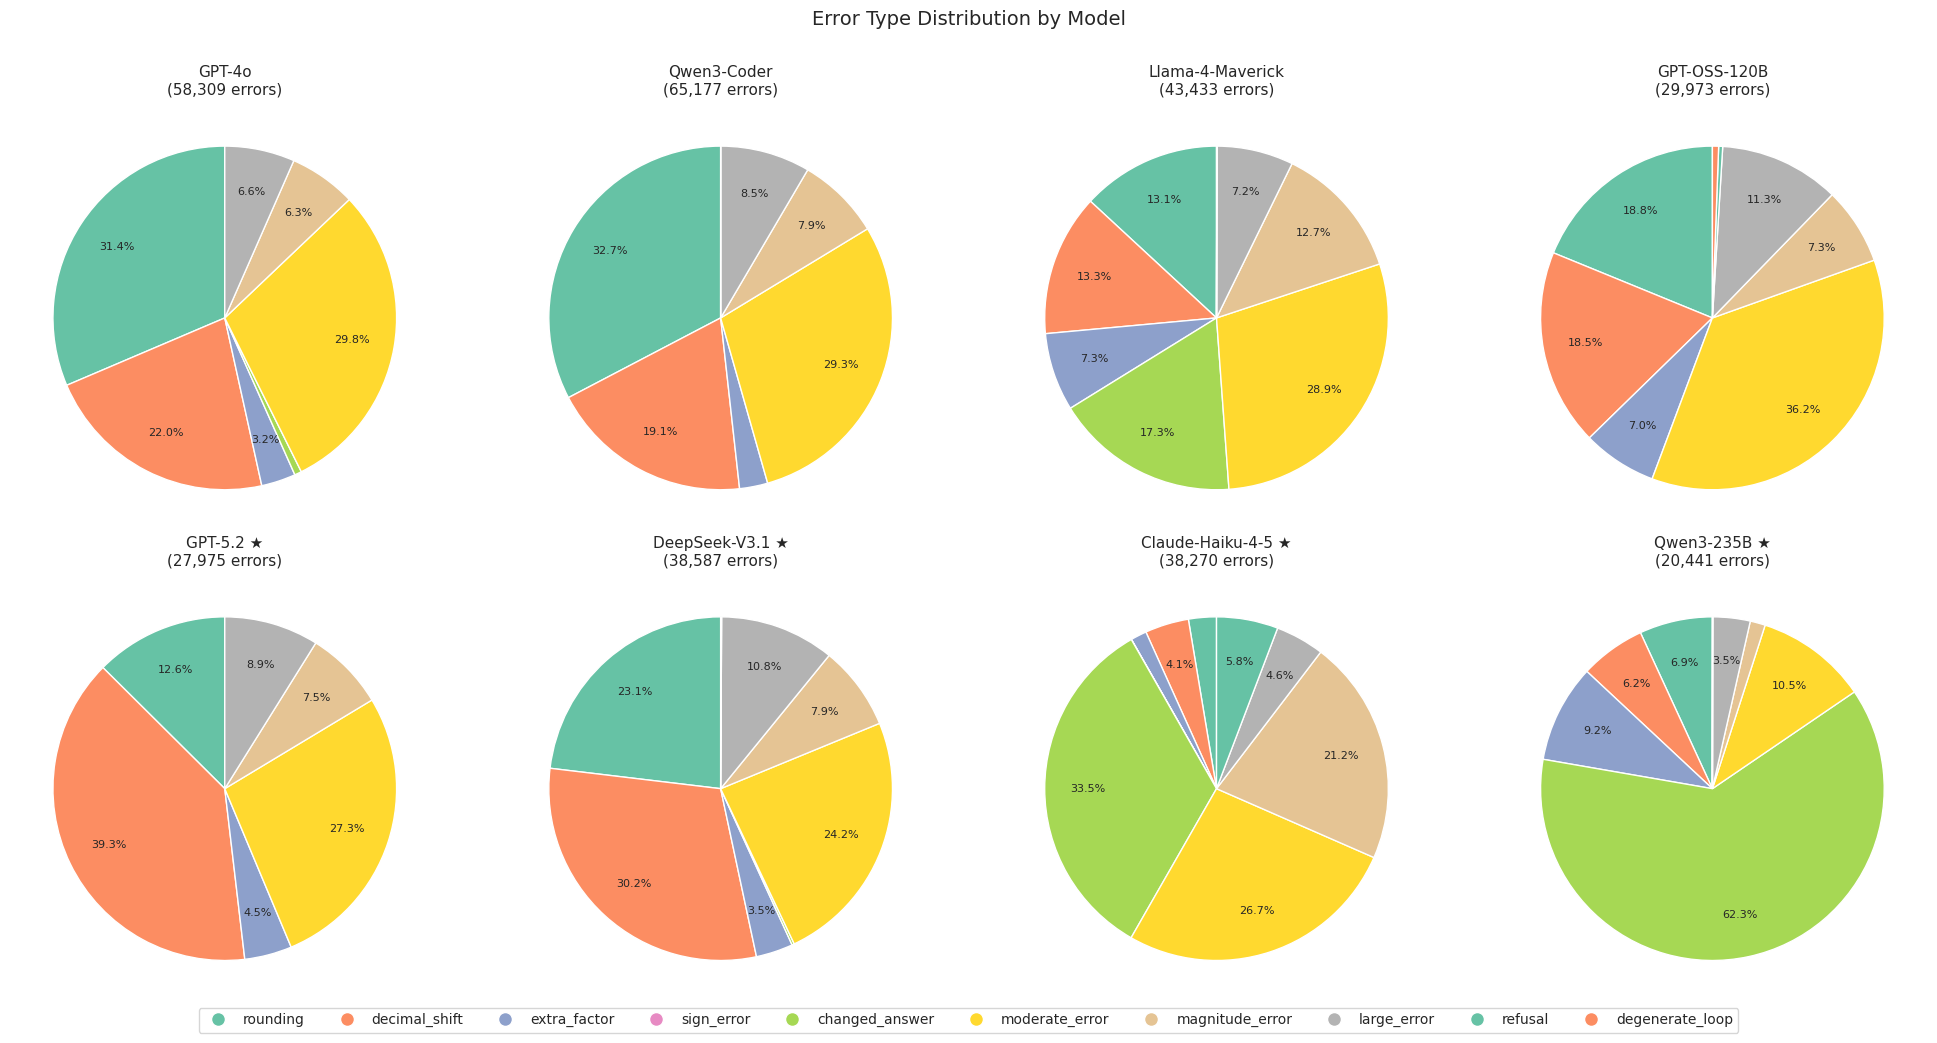

In [8]:
# Normalized stacked bar: error type percentage per model (replaces pie charts)
ct_norm = ct.div(ct.sum(axis=1), axis=0) * 100
models_present = [m for m in ALL_MODELS if m in ct_norm.index]
ct_norm = ct_norm.reindex(models_present)

fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN / 1.6))
labels = [MODEL_DISPLAY.get(m, m) + REASONING_MARKER.get(m, '') for m in ct_norm.index]
y = np.arange(len(ct_norm))
left = np.zeros(len(ct_norm))

for col in ct_norm.columns:
    vals = ct_norm[col].values.astype(float)
    bars = ax.barh(y, vals, left=left, label=col, color=ERROR_COLORS[col],
                   hatch=ERROR_HATCHES[col], edgecolor='white', linewidth=0.3, height=0.7)
    for j, (v, l) in enumerate(zip(vals, left)):
        if v > 5:
            ax.text(l + v / 2, j, f'{v:.0f}', ha='center', va='center', fontsize=6,
                    color='white' if v > 15 else 'black', fontweight='bold')
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('Percentage of Errors (%)')
ax.set_xlim(0, 100)
ax.set_title('Error Type Profile by Model (Normalized)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True,
          edgecolor='#cccccc', fancybox=False)
ax.invert_yaxis()
plt.tight_layout()
save_fig(fig, 'fig2_error_profile_by_model')
plt.show()

In [9]:
# Error type breakdown for TIMEZONE and CURRENCY domains

for domain_name in ['timezone', 'currency']:
    dom_errors = errors_only[errors_only['domain'] == domain_name].copy()
    if dom_errors.empty:
        print(f"No errors found for domain '{domain_name}'\n")
        continue

    print(f"\n{'='*60}")
    print(f"  DOMAIN: {domain_name.upper()}")
    print(f"{'='*60}")

    # Overall distribution for this domain
    overall = dom_errors['error_type'].value_counts()
    overall_pct = (overall / overall.sum() * 100).round(1)
    overall_df = pd.DataFrame({'count': overall, '%': overall_pct})
    overall_df = overall_df.reindex([c for c in error_order if c in overall_df.index])
    print(f"\n--- Overall Error Type Distribution ({domain_name}) ---")
    print(overall_df.to_string())
    print(f"\nTotal errors: {overall.sum():,}")

    # Per-model: each row sums to 100%
    print(f"\n--- Error Type % by Model ({domain_name}, row-normalized) ---")
    ct_pct = pd.crosstab(dom_errors['model'], dom_errors['error_type'], normalize='index') * 100
    ct_pct = ct_pct.reindex(index=[m for m in ALL_MODELS if m in ct_pct.index])
    ct_pct = ct_pct.reindex(columns=[c for c in error_order if c in ct_pct.columns])
    ct_pct['n_errors'] = dom_errors.groupby('model').size().reindex(ct_pct.index)
    print(ct_pct.round(1).to_string())

    # Per-model: share of total errors
    print(f"\n--- Model Share of Total Errors ({domain_name}) ---")
    model_share = dom_errors['model'].value_counts()
    model_share_pct = (model_share / model_share.sum() * 100).round(1)
    model_share_df = pd.DataFrame({'n_errors': model_share, '% of all errors': model_share_pct})
    model_share_df = model_share_df.reindex([m for m in ALL_MODELS if m in model_share_df.index])
    print(model_share_df.to_string())
    print()


  DOMAIN: TIMEZONE

--- Overall Error Type Distribution (timezone) ---
                 count     %
error_type                  
rounding           337   1.6
moderate_error    8577  39.6
large_error      12282  56.8
refusal            440   2.0
degenerate_loop      1   0.0

Total errors: 21,637

--- Error Type % by Model (timezone, row-normalized) ---
error_type           rounding  moderate_error  large_error  refusal  degenerate_loop  n_errors
model                                                                                         
gpt-4o                    2.0            25.6         72.4      0.0              0.0      2977
qwen-coder                0.9            51.9         47.2      0.0              0.0      5943
llama-4                   3.0            20.2         76.9      0.0              0.0      1949
gpt-oss-120b              0.0            45.8         54.2      0.0              0.0      1006
gpt-5.2                   0.2            23.4         76.3      0.0        

In [10]:
errors_only[errors_only['domain']=='currency']['error_type'].value_counts()

error_type
moderate_error     43845
magnitude_error    11586
rounding            9436
decimal_shift       9393
large_error         6754
changed_answer      2171
refusal             1749
extra_factor        1662
degenerate_loop        8
sign_error             5
Name: count, dtype: int64

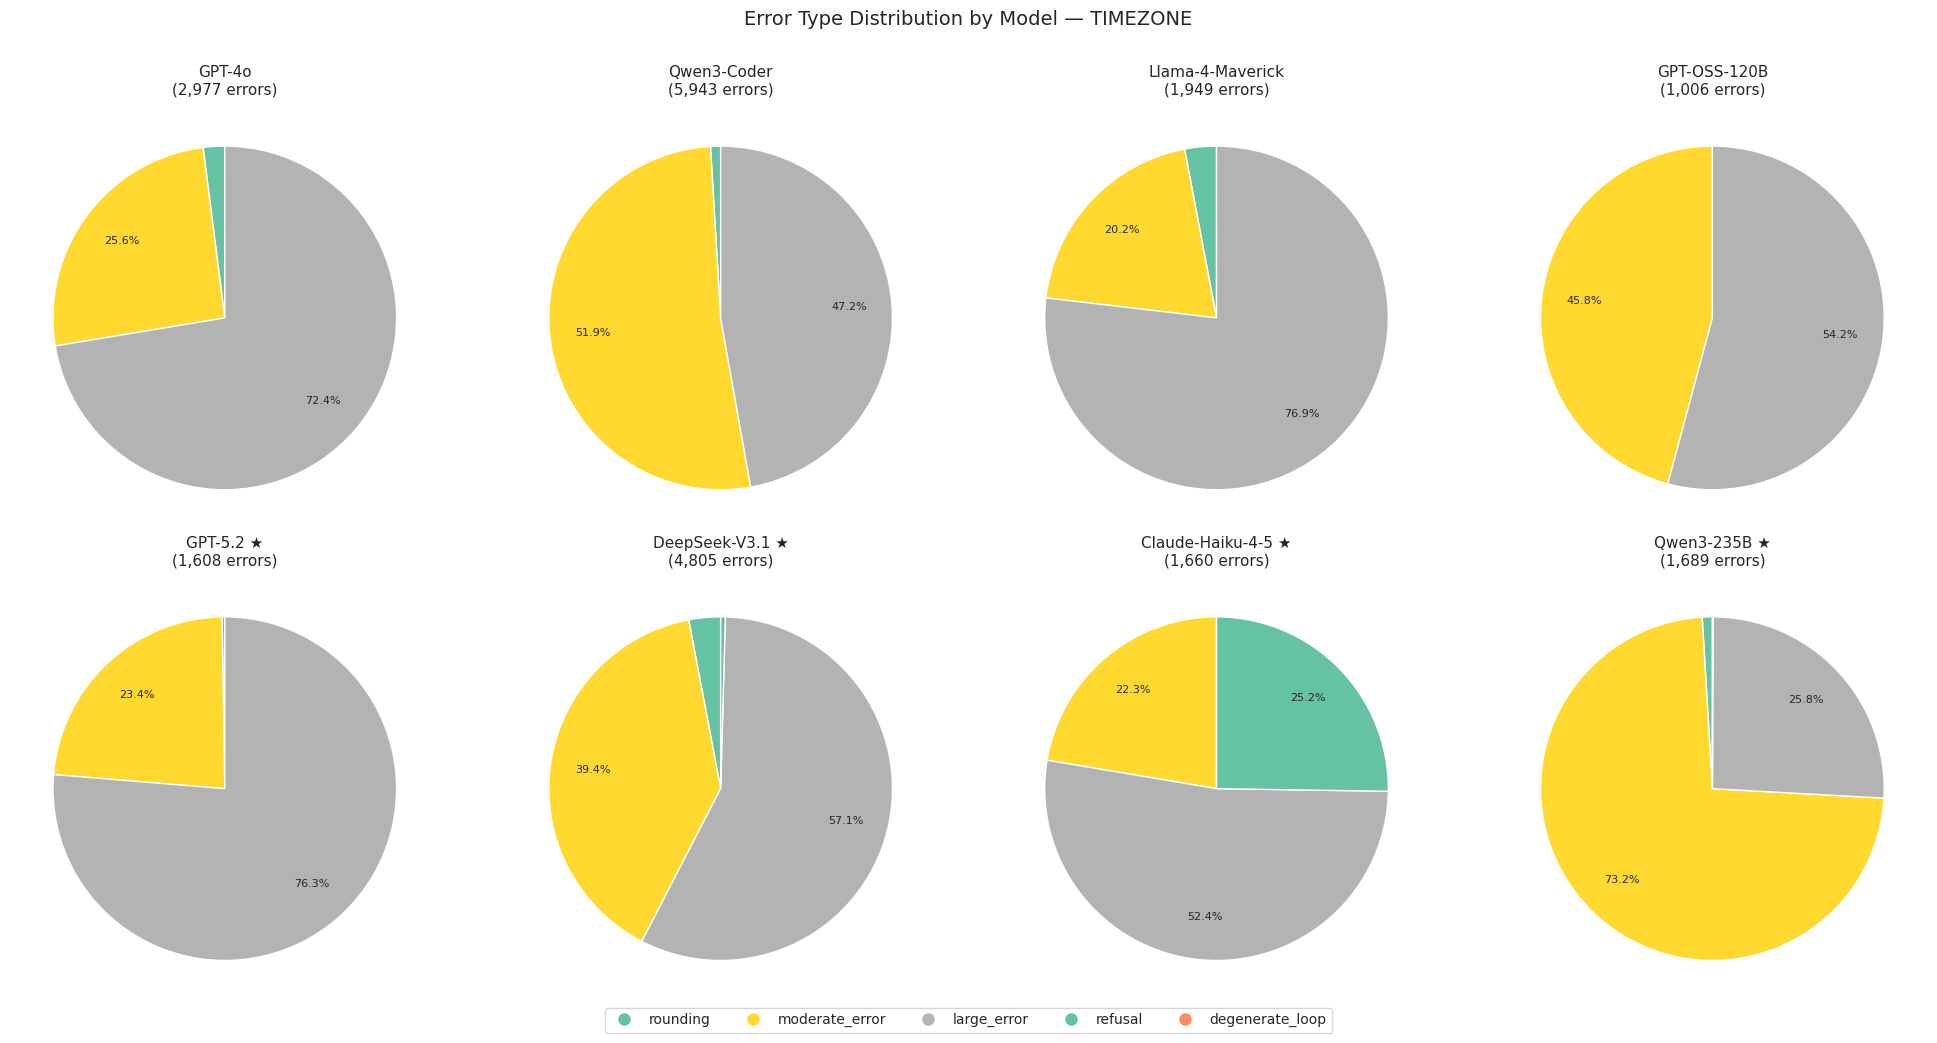

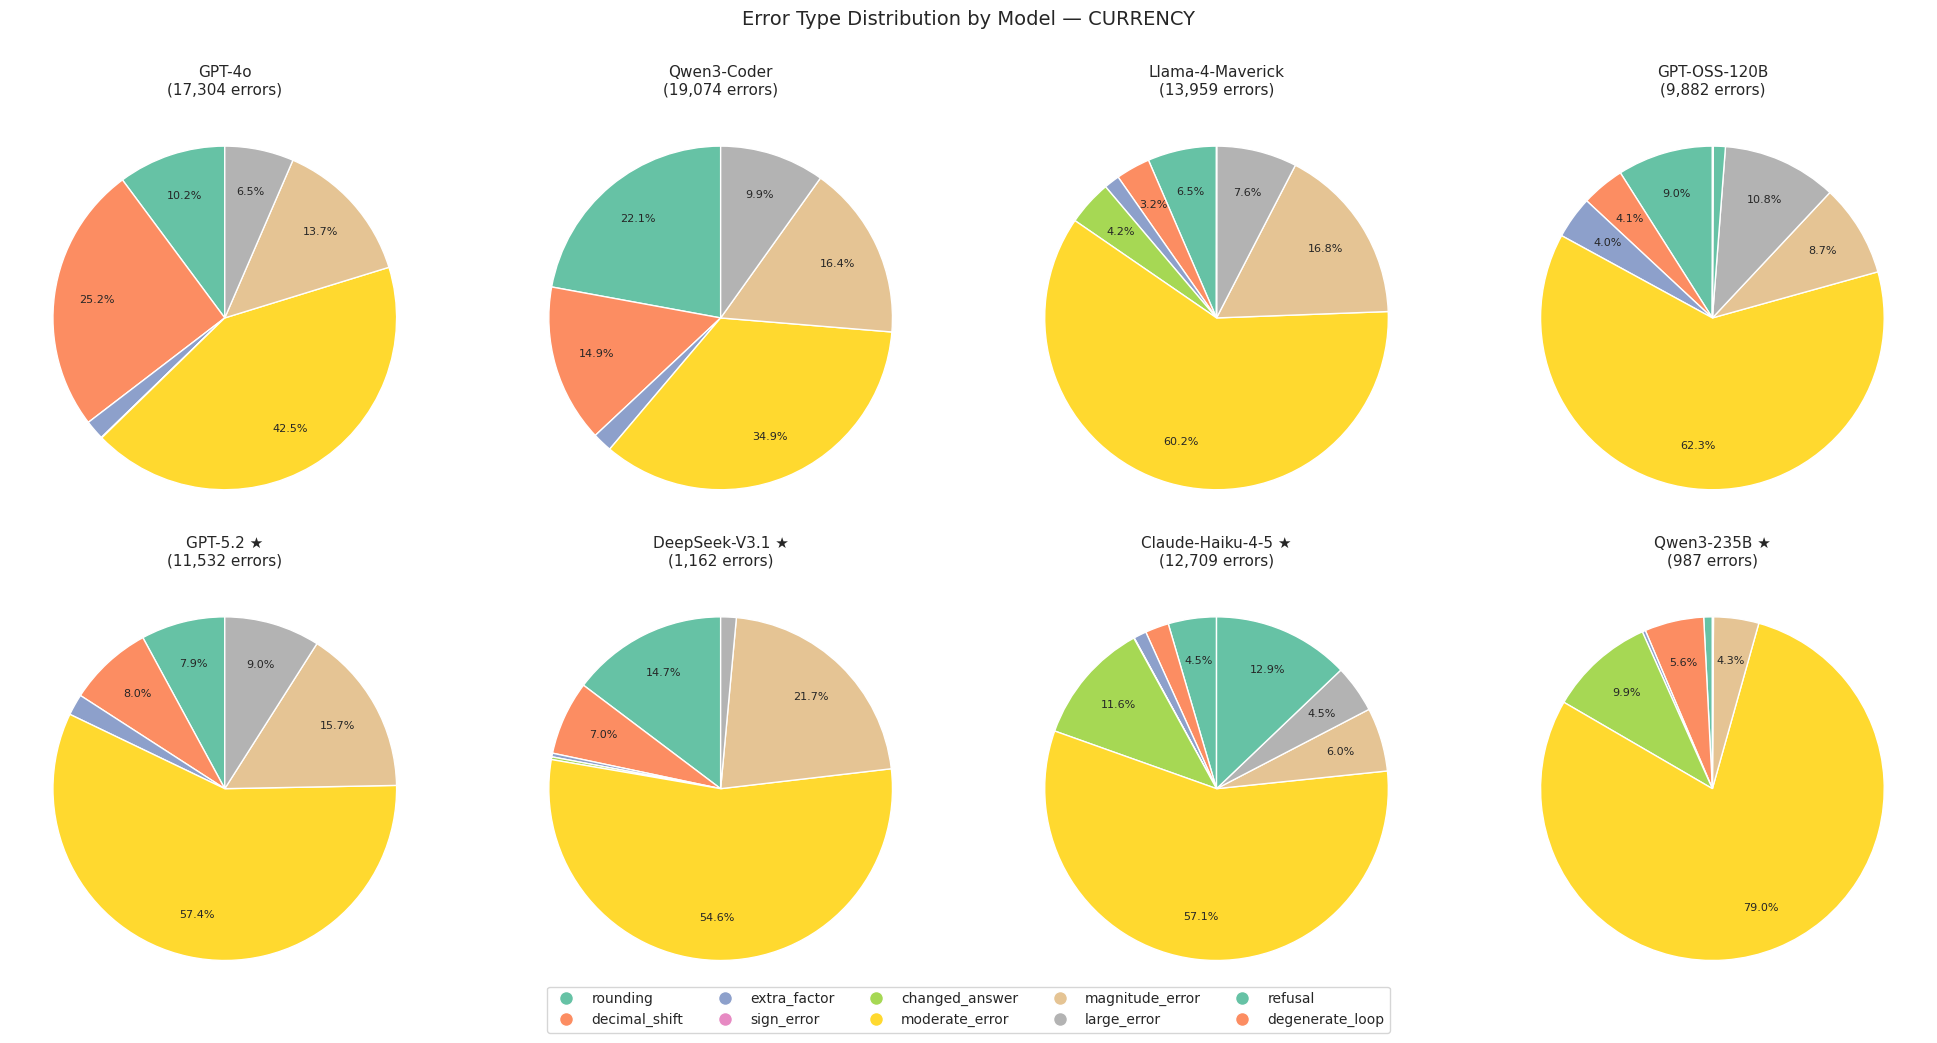

In [11]:
# Pie charts for TIMEZONE and CURRENCY domains

pie_colors = sns.color_palette('Set2', len(error_order))
color_map = dict(zip(error_order, pie_colors))

for domain_name in ['timezone', 'currency']:
    dom_errors = errors_only[errors_only['domain'] == domain_name].copy()
    if dom_errors.empty:
        continue

    models_with_errors = [m for m in ALL_MODELS if m in dom_errors['model'].unique()]
    n_models = len(models_with_errors)
    ncols = 4
    nrows = -(-n_models // ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = axes.flatten() if n_models > 1 else [axes]

    for idx, model in enumerate(models_with_errors):
        ax = axes[idx]
        model_errs = dom_errors[dom_errors['model'] == model]['error_type'].value_counts()
        model_errs = model_errs.reindex([e for e in error_order if e in model_errs.index]).dropna()

        colors = [color_map[e] for e in model_errs.index]
        wedges, texts, autotexts = ax.pie(
            model_errs.values, labels=None, autopct='%1.1f%%',
            colors=colors, startangle=90, pctdistance=0.75,
            textprops={'fontsize': 8}
        )
        for at, val in zip(autotexts, model_errs.values):
            if val / model_errs.sum() < 0.03:
                at.set_text('')

        display = MODEL_DISPLAY.get(model, model)
        ax.set_title(f'{display}\n({model_errs.sum():,} errors)', fontsize=11)

    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)

    legend_handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[e], markersize=10, label=e)
                      for e in error_order if e in dom_errors['error_type'].values]
    fig.legend(handles=legend_handles, loc='lower center', ncol=min(len(legend_handles), 5),
               fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(f'Error Type Distribution by Model — {domain_name.upper()}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [12]:
df[(df['error_type'] == 'changed_answer')].sample(100).to_csv('error_mappings/ex_changed_answer.csv', sep='\t', index=False)


In [13]:
df.columns

Index(['domain', 'distractor', 'prompt', 'number', 'answer', 'difficulty',
       'raw_response', 'model_answer', 'loss', 'reasoning_tokens',
       'call_seconds', 'model', 'condition', 'frequency', 'frequency_level',
       'is_reasoning', 'display_name', 'is_correct', 'num_decimals',
       'num_input_decimals', 'frequency_difficulty', 'error_type'],
      dtype='object')

In [14]:
df[(df['model']=='llama-4') & (df['error_type']=='changed_answer')].sample(30)

,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,...,condition,frequency,frequency_level,is_reasoning,display_name,is_correct,num_decimals,num_input_decimals,frequency_difficulty,error_type
625065,energy,carrot,Convert 75 joules of carrot to watt-hours.\n\n...,75.0,0.0208332934990439,Easy,## Step 1: Understand the given conversion fac...,0.0208,0.159809,0.0,...,in_domain_with_guide,10590900.0,common,False,Llama-4-Maverick,False,4,0,hard,changed_answer
606583,density,ammonia,Convert 95 kg/m³s of ammonia to lb/in³s.\n\nCo...,95.0,0.003432,Easy,## Step 1: Understand the given conversion pro...,0.0034,0.935078,0.0,...,in_domain_with_guide,17941224.0,very_common,False,Llama-4-Maverick,False,4,0,hard,changed_answer
1678507,density,oxygen,Convert 225 g/cm³s of oxygen to kg/m³s. Provid...,225.0,225000.0,Easy,<answer>225000.0000</answer> is not needed; th...,225.0,99.900000,0.0,...,in_domain_no_guide,1818945.0,common,False,Llama-4-Maverick,False,0,0,hard,changed_answer
1685884,density,hydrogen,Convert 75000 g/cm³s of hydrogen to lb/ft³s. P...,75000.0,4682097.15,Easy,<answer>4680.7755</answer> is not within the 4...,4682.0971,99.900000,0.0,...,in_domain_no_guide,256800.0,uncommon,False,Llama-4-Maverick,False,4,0,hard,changed_answer
610633,density,matcha latte,Convert 600 lb/in³s of matcha latte to kg/m³s....,600.0,16607942.82616,Easy,## Step 1: Understand the given conversion tas...,16605.9043,99.900012,0.0,...,in_domain_with_guide,4356594.0,common,False,Llama-4-Maverick,False,4,0,hard,changed_answer
1689332,density,astatine,Convert 10 kg/m³s of astatine to lb/in³s. Prov...,10.0,0.000361,Easy,"To solve this, we need to convert kg/m³ to lb/...",0.0004,10.719619,0.0,...,in_domain_no_guide,156505596.0,very_common,False,Llama-4-Maverick,False,4,0,easy,changed_answer
605218,density,ethanol,Convert 2 kg/m³s of ethanol to lb/in³s.\n\nCon...,2.0,0.000072,Easy,## Step 1: Understand the given conversion pro...,0.0001,38.399524,0.0,...,in_domain_with_guide,789731532.0,very_common,False,Llama-4-Maverick,False,4,0,easy,changed_answer
605489,density,water,Convert 11 kg/m³s of water to lb/in³s.\n\nConv...,11.0,0.000397,Easy,## Step 1: Understand the given conversion pro...,0.0004,0.654199,0.0,...,in_domain_with_guide,76986440.0,very_common,False,Llama-4-Maverick,False,4,0,hard,changed_answer
605324,density,spit,Convert 5 kg/m³s of spit to lb/in³s.\n\nConver...,5.0,0.000181,Easy,"To convert 5 kg/m³s to lb/in³s, we first need ...",0.0002,10.719619,0.0,...,in_domain_with_guide,246823466.0,very_common,False,Llama-4-Maverick,False,4,0,easy,changed_answer
624508,energy,potato,Convert 25 joules of potato to watt-hours.\n\n...,25.0,0.0069444311663479,Easy,## Step 1: Understand the given conversion fac...,0.0069,0.639810,0.0,...,in_domain_with_guide,39537786.0,very_common,False,Llama-4-Maverick,False,4,0,hard,changed_answer


### 2.2 Error Type Distribution by Condition

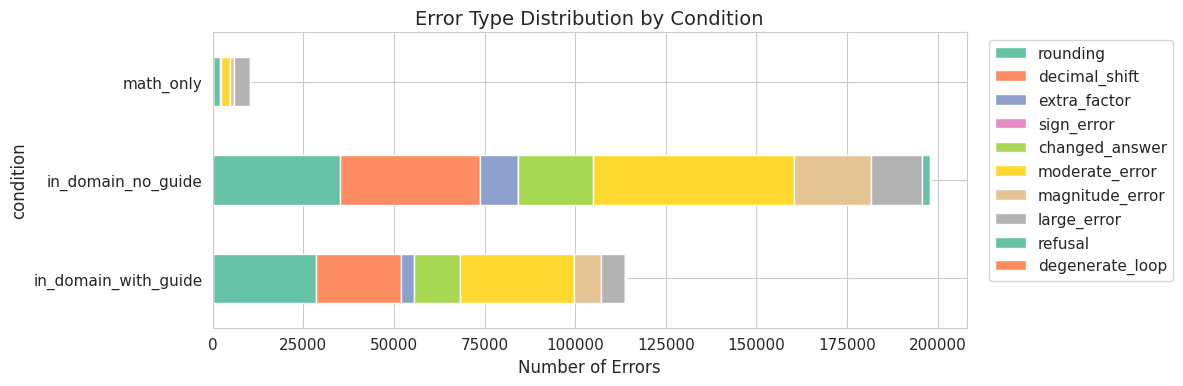


Error counts by condition:
error_type            rounding  decimal_shift  extra_factor  sign_error  changed_answer  moderate_error  magnitude_error  large_error  refusal  degenerate_loop
condition                                                                                                                                                      
in_domain_with_guide     28667          23213          3565           0           12823           31315             7504         6659       11              137
in_domain_no_guide       35149          38650         10382           5           20622           55461            21273        14061     2357               53
math_only                 1970            272             5           0              87            2390             1262         4271        0                1


In [15]:
ct_cond = pd.crosstab(errors_only['condition'], errors_only['error_type'])
ct_cond = ct_cond.reindex(index=['in_domain_with_guide', 'in_domain_no_guide', 'math_only'])
ct_cond = ct_cond.reindex(columns=[c for c in error_order if c in ct_cond.columns])

fig, ax = plt.subplots(figsize=(PAGE_W, COL_W / GOLDEN))
labels = [CONDITION_DISPLAY.get(c, c) for c in ct_cond.index]
y = np.arange(len(ct_cond))
left = np.zeros(len(ct_cond))
for col in ct_cond.columns:
    vals = ct_cond[col].values.astype(float)
    ax.barh(y, vals, left=left, label=col, color=ERROR_COLORS[col],
            hatch=ERROR_HATCHES[col], edgecolor='white', linewidth=0.3, height=0.5)
    left += vals
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('Number of Errors')
ax.set_title('Error Type Distribution by Condition')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True,
          edgecolor='#cccccc', fancybox=False)
ax.invert_yaxis()
plt.tight_layout()
save_fig(fig, 'fig3_error_by_condition')
plt.show()

# Publication table
ct_cond_pct = ct_cond.div(ct_cond.sum(axis=1), axis=0) * 100
ct_cond_pct.index = [CONDITION_DISPLAY.get(c, c) for c in ct_cond_pct.index]
ct_cond_pct['N'] = ct_cond.sum(axis=1).values
ct_cond_pct.index.name = 'Condition'
print("\nTABLE: Error Type % by Condition")
print(ct_cond_pct.round(1).to_string())
print("\n--- LaTeX ---")
print(ct_cond_pct.round(1).to_latex(caption='Error type distribution (\\%) by condition.',
                                     label='tab:error_by_condition'))

### 2.3 Error Type Distribution by Domain

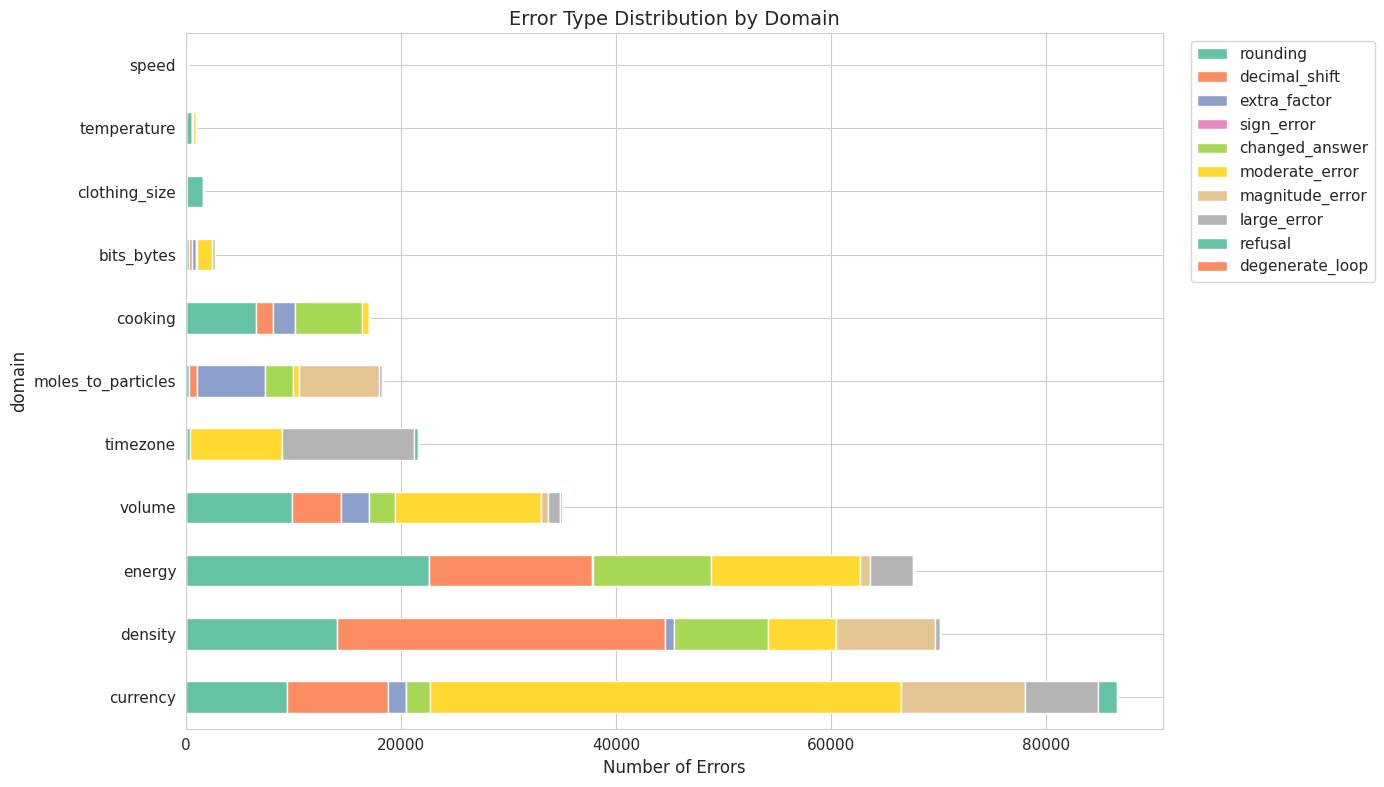

In [16]:
ct_dom = pd.crosstab(errors_only['domain'], errors_only['error_type'])
ct_dom = ct_dom.reindex(columns=[c for c in error_order if c in ct_dom.columns])
ct_dom = ct_dom.loc[ct_dom.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN / 1.3))
labels = ct_dom.index.tolist()
y = np.arange(len(ct_dom))
left = np.zeros(len(ct_dom))
for col in ct_dom.columns:
    vals = ct_dom[col].values.astype(float)
    ax.barh(y, vals, left=left, label=col, color=ERROR_COLORS[col],
            hatch=ERROR_HATCHES[col], edgecolor='white', linewidth=0.3, height=0.7)
    left += vals
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('Number of Errors')
ax.set_title('Error Type Distribution by Domain')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True,
          edgecolor='#cccccc', fancybox=False)
ax.invert_yaxis()
plt.tight_layout()
save_fig(fig, 'fig4_error_by_domain')
plt.show()

# Publication table
ct_dom_pct = ct_dom.div(ct_dom.sum(axis=1), axis=0) * 100
ct_dom_pct['N'] = ct_dom.sum(axis=1)
ct_dom_pct.index.name = 'Domain'
print("\nTABLE: Error Type % by Domain")
print(ct_dom_pct.round(1).to_string())
print("\n--- LaTeX ---")
print(ct_dom_pct.round(1).to_latex(caption='Error type distribution (\\%) by domain.',
                                    label='tab:error_by_domain'))

## 3. Math-Only vs No-Guide Discrepancy

Find cases where the model solved the math-only (pure arithmetic) version correctly but failed the no-guide (domain-phrased) version — same underlying conversion, same gold answer.

In [17]:
# Separate math_only and no_guide data
mo = df[df['condition'] == 'math_only'].copy()
ng = df[df['condition'] == 'in_domain_no_guide'].copy()

# Exclude clothing (no math_only equivalent)
ng = ng[~ng['domain'].str.contains('clothing')]

# Create join keys: model + domain + number + gold answer
mo['key'] = mo['model'] + '|' + mo['domain'] + '|' + mo['number'].astype(str) + '|' + mo['answer'].astype(str)
ng['key'] = ng['model'] + '|' + ng['domain'] + '|' + ng['number'].astype(str) + '|' + ng['answer'].astype(str)

# Filter: no distractor rows only (for fair comparison)
for d in [mo, ng]:
    mask = d['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | d['distractor'].isna()
    d.drop(d[~mask].index, inplace=True)

mo_correct_keys = set(mo[mo['loss'] == 0]['key'].values)
ng_wrong = ng[ng['loss'] > 0].copy()

# Math correct AND no-guide wrong
ng_wrong['math_correct'] = ng_wrong['key'].isin(mo_correct_keys)
discrepant = ng_wrong[ng_wrong['math_correct']].copy()

print(f"Total no-guide wrong rows: {len(ng_wrong):,}")
print(f"Of which math-only was correct: {len(discrepant):,} ({len(discrepant)/max(len(ng_wrong),1)*100:.1f}%)")
print(f"\nBreakdown by model:")
print(discrepant.groupby('model').size().to_string())

Total no-guide wrong rows: 84,371
Of which math-only was correct: 36,020 (42.7%)

Breakdown by model:
model
claude-haiku-4-5       12652
deepseek-v3.1           2473
gpt-4o                  1885
gpt-5.2                 1761
gpt-oss-120b            9838
llama-4                 1720
qwen-coder              4167
qwen3-235b-thinking     1524


### 3.1 Discrepancy Rate by Model × Domain

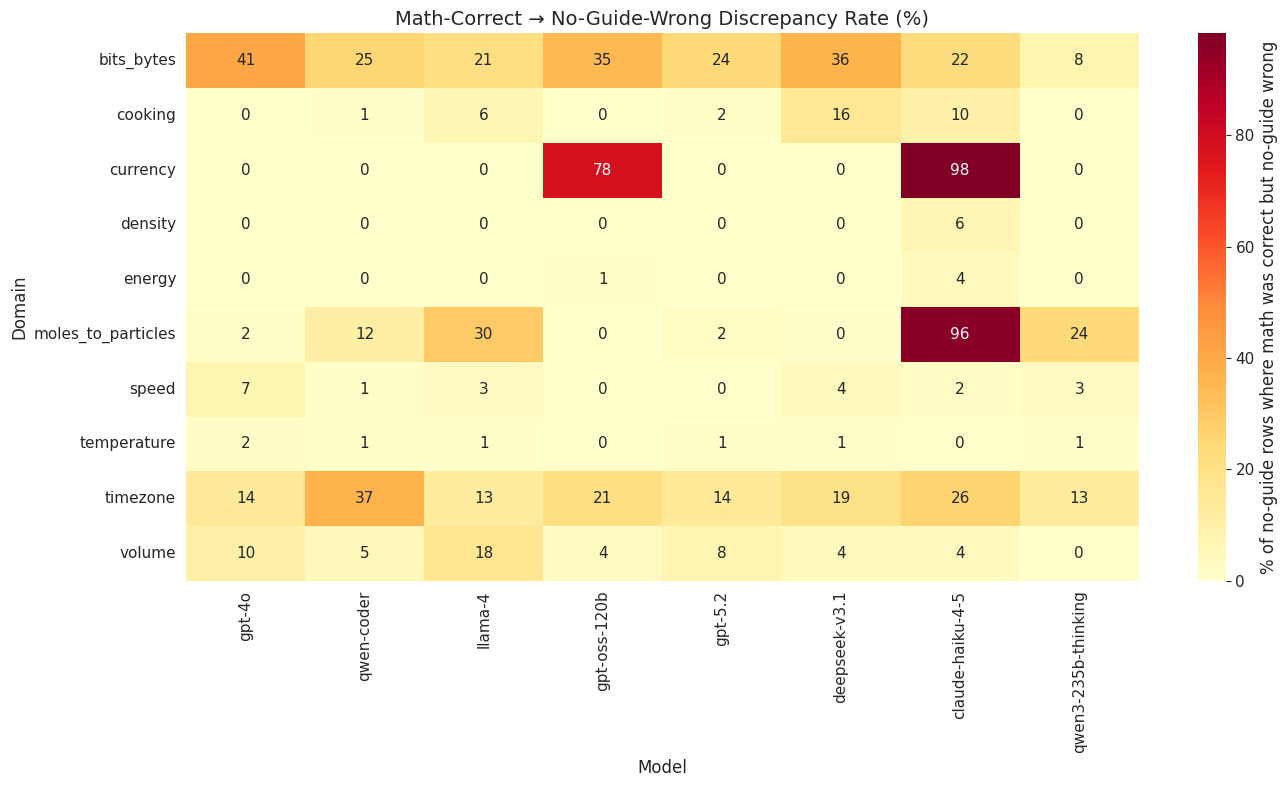

In [18]:
disc_counts = discrepant.groupby(['model', 'domain']).size().reset_index(name='disc_count')
ng_nodist_total = ng.copy()
ng_totals = ng_nodist_total.groupby(['model', 'domain']).size().reset_index(name='total')

disc_rate = disc_counts.merge(ng_totals, on=['model', 'domain'], how='left')
disc_rate['disc_pct'] = (disc_rate['disc_count'] / disc_rate['total'] * 100).round(1)

pivot = disc_rate.pivot(index='domain', columns='model', values='disc_pct').fillna(0)
pivot = pivot.reindex(columns=[m for m in ALL_MODELS if m in pivot.columns])

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': '% of no-guide rows where math was correct but no-guide wrong'})
ax.set_title('Math-Correct → No-Guide-Wrong Discrepancy Rate (%)')
ax.set_ylabel('Domain')
ax.set_xlabel('Model')
plt.tight_layout()
plt.show()

### 3.2 Error Types in Discrepant Cases

When the model got the math right but the domain version wrong — what kind of error did it make?

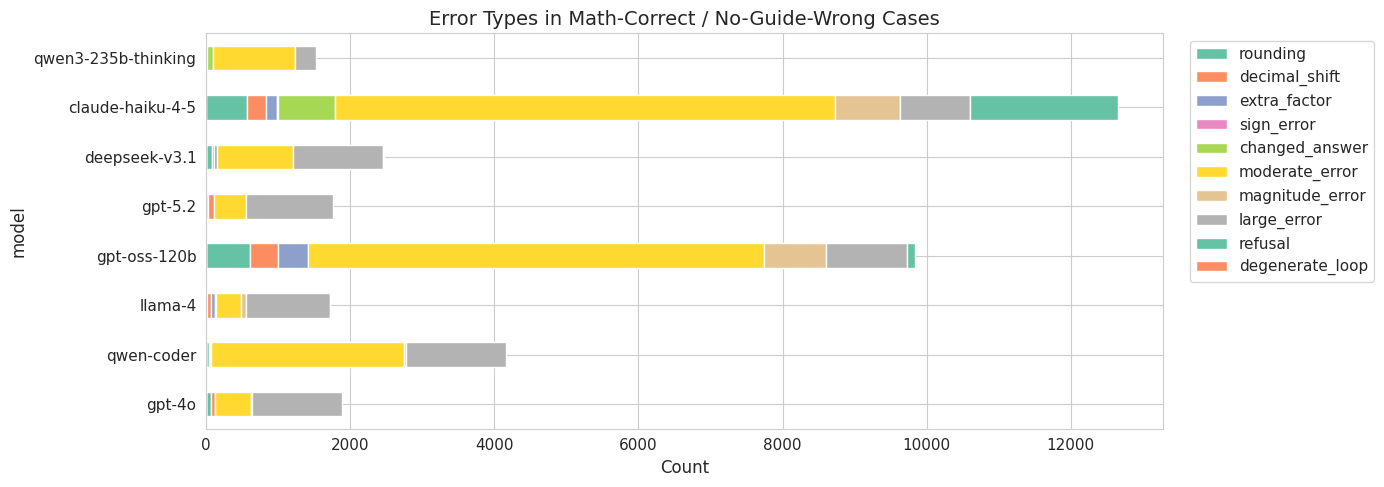

error_type           rounding  decimal_shift  extra_factor  sign_error  changed_answer  moderate_error  magnitude_error  large_error  refusal  degenerate_loop
model                                                                                                                                                         
gpt-4o                     68             48             1           0               0             511                8         1249        0                0
qwen-coder                 45             10            13           0               0            2678               23         1398        0                0
llama-4                    15             56            52           0              13             346               67         1165        0                6
gpt-oss-120b              615            388           410           0               0            6334              853         1126      112                0
gpt-5.2                    32             73  

In [19]:
discrepant['error_type'] = discrepant.apply(classify_error, axis=1)

disc_et = pd.crosstab(discrepant['model'], discrepant['error_type'])
disc_et = disc_et.reindex(index=[m for m in ALL_MODELS if m in disc_et.index])
disc_et = disc_et.reindex(columns=[c for c in error_order if c in disc_et.columns])

fig, ax = plt.subplots(figsize=(14, 5))
disc_et.plot(kind='barh', stacked=True, ax=ax,
             color=sns.color_palette('Set2', len(disc_et.columns)))
ax.set_xlabel('Count')
ax.set_title('Error Types in Math-Correct / No-Guide-Wrong Cases')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(disc_et.to_string())

### 3.3 Example Traces: Math Correct but No-Guide Wrong

Show concrete prompt/response pairs for the most interesting discrepancies.

In [20]:
def show_discrepancy(model_name, domain_name, n=3, min_loss=5):
    """Print side-by-side math-only vs no-guide for a given model and domain."""
    sub = discrepant[(discrepant['model'] == model_name) & (discrepant['domain'] == domain_name)]
    sub = sub[sub['loss'] > min_loss].sort_values('loss', ascending=False).head(n)
    
    if len(sub) == 0:
        print(f"  No discrepancies with loss > {min_loss} for {model_name} / {domain_name}")
        return
    
    for _, row in sub.iterrows():
        key = row['key']
        mo_match = mo[mo['key'] == key]
        if len(mo_match) == 0:
            continue
        mo_row = mo_match.iloc[0]
        
        print(f"{'='*80}")
        print(f"Model: {model_name} | Domain: {domain_name} | Number: {row['number']} | Gold: {row['answer']}")
        print(f"Error type: {row['error_type']} | Loss: {row['loss']:.1f}")
        print(f"{'─'*80}")
        print(f"MATH-ONLY prompt:  {mo_row['prompt']}")
        print(f"MATH-ONLY answer:  {str(mo_row['raw_response'])[:300]}")
        print(f"{'─'*80}")
        print(f"NO-GUIDE prompt:   {row['prompt'][:300]}")
        print(f"NO-GUIDE answer:   {str(row['raw_response'])[:500]}")
        print()


focus_models = ['gpt-4o', 'qwen3-235b-thinking']
focus_domains = ['temperature', 'density', 'volume', 'cooking', 'speed', 'currency', 'timezone']

for m in focus_models:
    print(f"\n{'#'*80}")
    print(f"### {MODEL_DISPLAY.get(m, m)}")
    print(f"{'#'*80}")
    for d in focus_domains:
        sub = discrepant[(discrepant['model'] == m) & (discrepant['domain'] == d)]
        if len(sub) > 0:
            print(f"\n--- {d} ({len(sub)} discrepancies) ---")
            show_discrepancy(m, d, n=2)


################################################################################
### GPT-4o
################################################################################

--- temperature (12 discrepancies) ---
Model: gpt-4o | Domain: temperature | Number: 75000 | Gold: 75273.15
Error type: decimal_shift | Loss: 896.7
────────────────────────────────────────────────────────────────────────────────
MATH-ONLY prompt:  what is 75000+273.15
MATH-ONLY answer:  <answer>75273.15</answer>
────────────────────────────────────────────────────────────────────────────────
NO-GUIDE prompt:   Convert 75000 degrees Celsius to Kelvin. Provide only the numerical value.
NO-GUIDE answer:   <answer>750273.15</answer>

Model: gpt-4o | Domain: temperature | Number: 50000 | Gold: 50273.15
Error type: decimal_shift | Loss: 895.1
────────────────────────────────────────────────────────────────────────────────
MATH-ONLY prompt:  what is 50000+273.15
MATH-ONLY answer:  <answer>50273.15</answer>
──────────────

## 4. Cross-Domain Error Analysis

For a given model and input number, when is the model correct in one domain but wrong in another?  
This reveals whether errors are *input-dependent* or *domain-dependent*.

In [21]:
def find_cross_domain_errors(df_in, model_name, condition='in_domain_with_guide', min_loss=5):
    """Find input numbers that are correct in some domains and wrong in others.
    
    Returns a DataFrame with one row per (number, correct_domain, wrong_domain) triplet.
    """
    sub = df_in[(df_in['model'] == model_name) & (df_in['condition'] == condition)].copy()
    
    # Filter to no-distractor
    mask = sub['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | sub['distractor'].isna()
    sub = sub[mask]
    
    # Numeric numbers only (exclude time strings)
    sub = sub[sub['number'].str.match(r'^-?\d+\.?\d*$', na=False)]
    
    correct = sub[sub['loss'] == 0]
    wrong = sub[sub['loss'] > min_loss]
    
    results = []
    for num in wrong['number'].unique():
        c_doms = set(correct[correct['number'] == num]['domain'].unique())
        w_rows = wrong[wrong['number'] == num]
        for _, w_row in w_rows.iterrows():
            w_dom = w_row['domain']
            for c_dom in c_doms:
                if c_dom != w_dom:
                    c_row = correct[(correct['number'] == num) & (correct['domain'] == c_dom)].iloc[0]
                    results.append({
                        'number': num,
                        'correct_domain': c_dom,
                        'correct_gold': c_row['answer'],
                        'wrong_domain': w_dom,
                        'wrong_gold': w_row['answer'],
                        'wrong_response': str(w_row['raw_response'])[:200],
                        'wrong_loss': w_row['loss'],
                        'wrong_error_type': w_row.get('error_type', ''),
                    })
    return pd.DataFrame(results)


print("Computing cross-domain errors for each model (with-guide condition)...")
cross_domain_results = {}
for m in ALL_MODELS:
    cde = find_cross_domain_errors(df, m, condition='in_domain_with_guide', min_loss=5)
    if len(cde) > 0:
        cross_domain_results[m] = cde
        print(f"  {m}: {len(cde):,} cross-domain error pairs")
    else:
        print(f"  {m}: no cross-domain errors found")

Computing cross-domain errors for each model (with-guide condition)...
  gpt-4o: 1,199 cross-domain error pairs
  qwen-coder: 722 cross-domain error pairs
  llama-4: 5,415 cross-domain error pairs
  gpt-oss-120b: 719 cross-domain error pairs
  gpt-5.2: 2,076 cross-domain error pairs
  deepseek-v3.1: 783 cross-domain error pairs
  claude-haiku-4-5: 7,045 cross-domain error pairs
  qwen3-235b-thinking: 303 cross-domain error pairs


### 4.1 Which Domains Fail When Others Succeed?

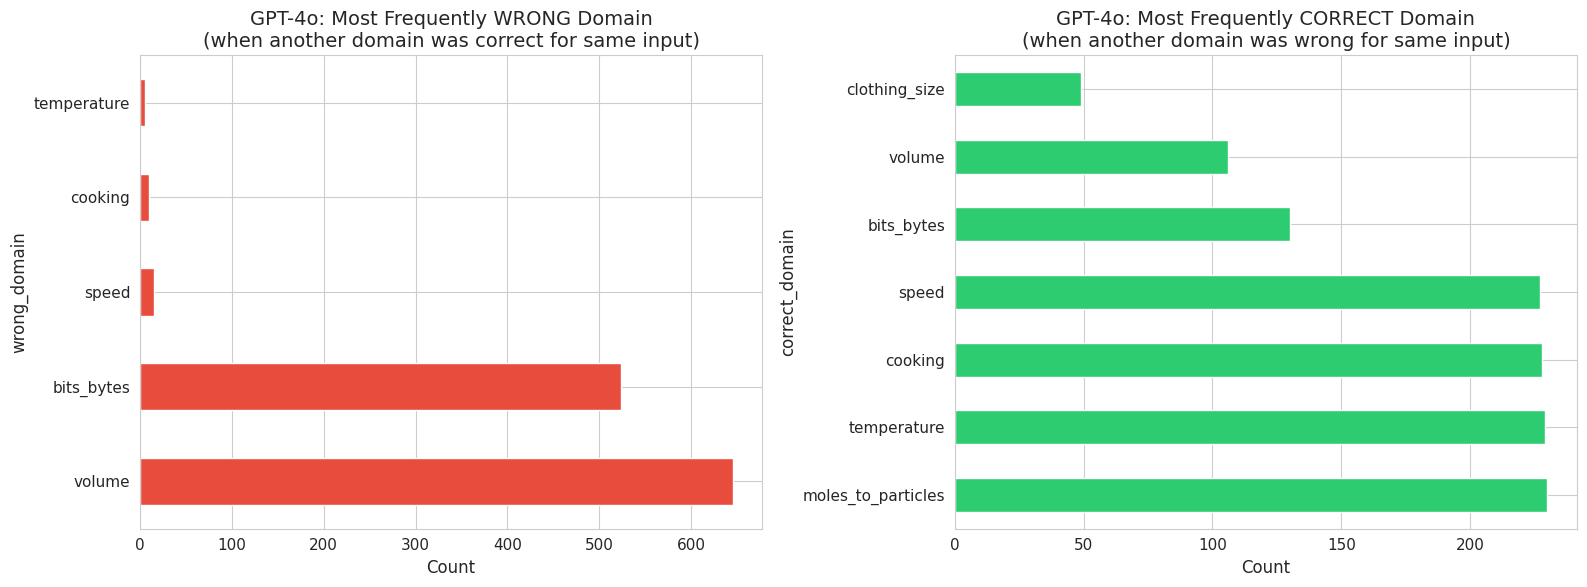

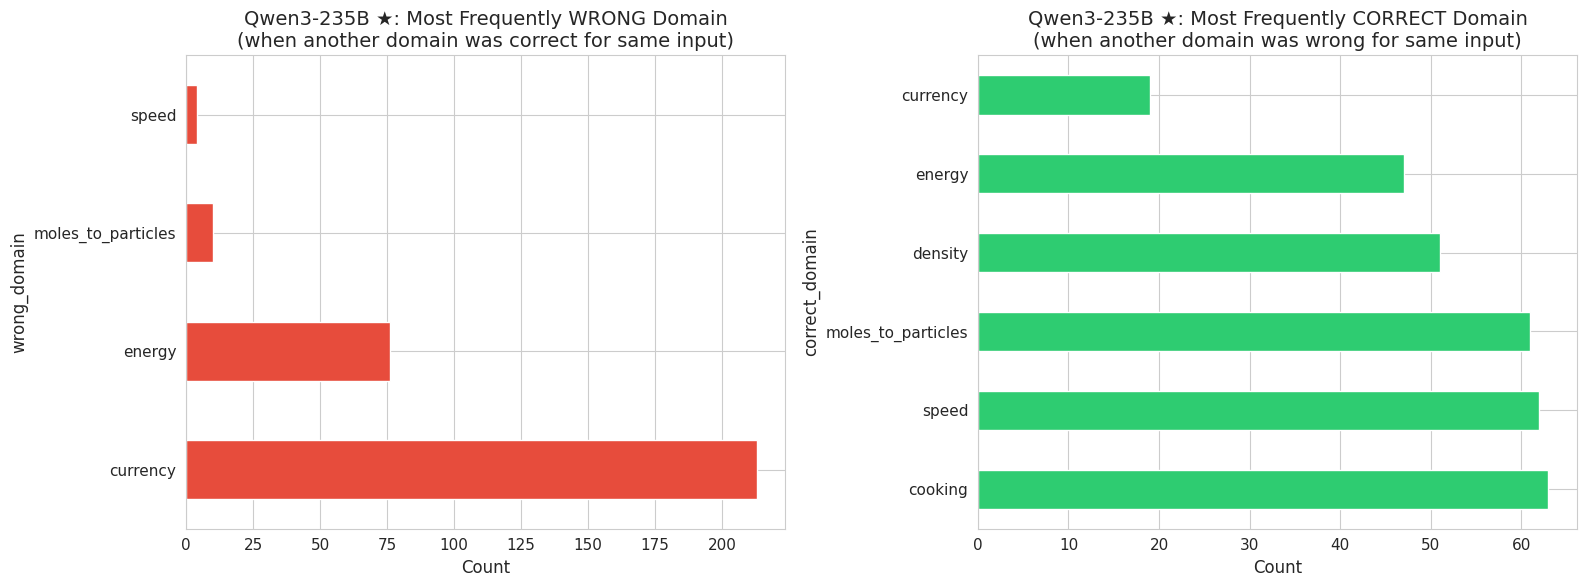

In [22]:
for model_name in ['gpt-4o', 'qwen3-235b-thinking']:
    if model_name not in cross_domain_results:
        continue
    cde = cross_domain_results[model_name]
    
    # Count how often each domain appears as the "wrong" one vs "correct" one
    wrong_counts = cde['wrong_domain'].value_counts().head(10)
    correct_counts = cde['correct_domain'].value_counts().head(10)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    wrong_counts.plot(kind='barh', ax=ax1, color='#e74c3c')
    ax1.set_title(f'{MODEL_DISPLAY.get(model_name, model_name)}: Most Frequently WRONG Domain\n(when another domain was correct for same input)')
    ax1.set_xlabel('Count')
    
    correct_counts.plot(kind='barh', ax=ax2, color='#2ecc71')
    ax2.set_title(f'{MODEL_DISPLAY.get(model_name, model_name)}: Most Frequently CORRECT Domain\n(when another domain was wrong for same input)')
    ax2.set_xlabel('Count')
    
    plt.tight_layout()
    plt.show()

### 4.2 Cross-Domain Error Heatmap

Row = domain that was wrong, Column = domain that was correct, Cell = how many shared input numbers.

### 4.3 Cross-Domain Example Traces

In [23]:
def show_cross_domain_trace(df_in, model_name, number, condition='in_domain_with_guide'):
    """Show how one model handled the same input number across all domains."""
    sub = df_in[(df_in['model'] == model_name) 
                & (df_in['condition'] == condition) 
                & (df_in['number'] == str(number))].copy()
    mask = sub['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | sub['distractor'].isna()
    sub = sub[mask]
    
    if len(sub) == 0:
        print(f"No data for {model_name} / number={number} / {condition}")
        return
    
    print(f"{'='*90}")
    print(f"Model: {model_name} | Input number: {number} | Condition: {condition}")
    print(f"{'='*90}")
    
    # Deduplicate by domain+answer to show one row per conversion
    seen = set()
    for _, row in sub.sort_values('domain').iterrows():
        dkey = f"{row['domain']}|{row['answer']}"
        if dkey in seen:
            continue
        seen.add(dkey)
        
        status = 'CORRECT' if row['loss'] == 0 else f"WRONG (loss={row['loss']:.1f})"
        etype = row.get('error_type', '')
        if etype and etype != 'correct':
            status += f" [{etype}]"
        
        prompt_short = row['prompt'][:120].replace('\n', ' ')
        resp_short = str(row['raw_response'])[:150].replace('\n', ' ')
        
        print(f"\n  {row['domain']:30s}  {status}")
        print(f"    Gold: {row['answer']}")
        print(f"    Prompt:   {prompt_short}...")
        print(f"    Response: {resp_short}...")


# Show a few interesting numbers
print("\n" + "#"*90)
print("GPT-4o with guide — input number = 3")
show_cross_domain_trace(df, 'gpt-4o', '3.0', 'in_domain_with_guide')

print("\n" + "#"*90)
print("GPT-4o with guide — input number = 75000")
show_cross_domain_trace(df, 'gpt-4o', '75000.0', 'in_domain_with_guide')


##########################################################################################
GPT-4o with guide — input number = 3
Model: gpt-4o | Input number: 3.0 | Condition: in_domain_with_guide

  moles_to_particles              CORRECT
    Gold: 1.806642228e+24
    Prompt:   Convert 3 moles to particles.  Conversion guide: Conversion factors (relative to moles):   atoms: 6.02214076e+23   moles...
    Response: 1.806642228e+24...

##########################################################################################
GPT-4o with guide — input number = 75000
Model: gpt-4o | Input number: 75000.0 | Condition: in_domain_with_guide

  energy                          CORRECT
    Gold: 75000000.0
    Prompt:   Convert 75000 kilojoules to joules.  Conversion guide: Conversion factors (relative to kilocalories):   btu: 3.96567   c...
    Response: <answer>75000000</answer>...

  moles_to_particles              CORRECT
    Gold: 4.51660557e+28
    Prompt:   Convert 75000 moles to particle

## 5. Condition Comparison: With Guide vs No Guide vs Math Only

For each model and domain, compare accuracy rates across the three conditions.


Accuracy (%) by condition — GPT-4o
condition           in_domain_with_guide  in_domain_no_guide  math_only  math−noguide  guide−noguide
domain                                                                                              
bits_bytes                          75.7                52.5       93.2          40.7           23.2
clothing_size                       99.6                39.2        NaN           NaN           60.4
cooking                             96.3                94.7       99.0           4.3            1.6
currency                            54.0                 0.3       91.2          90.9           53.7
density                             73.5                62.5       92.3          29.8           11.0
energy                              85.9                91.1       97.5           6.4           -5.2
moles_to_particles                 100.0                98.5      100.0           1.5            1.5
speed                               99.3               

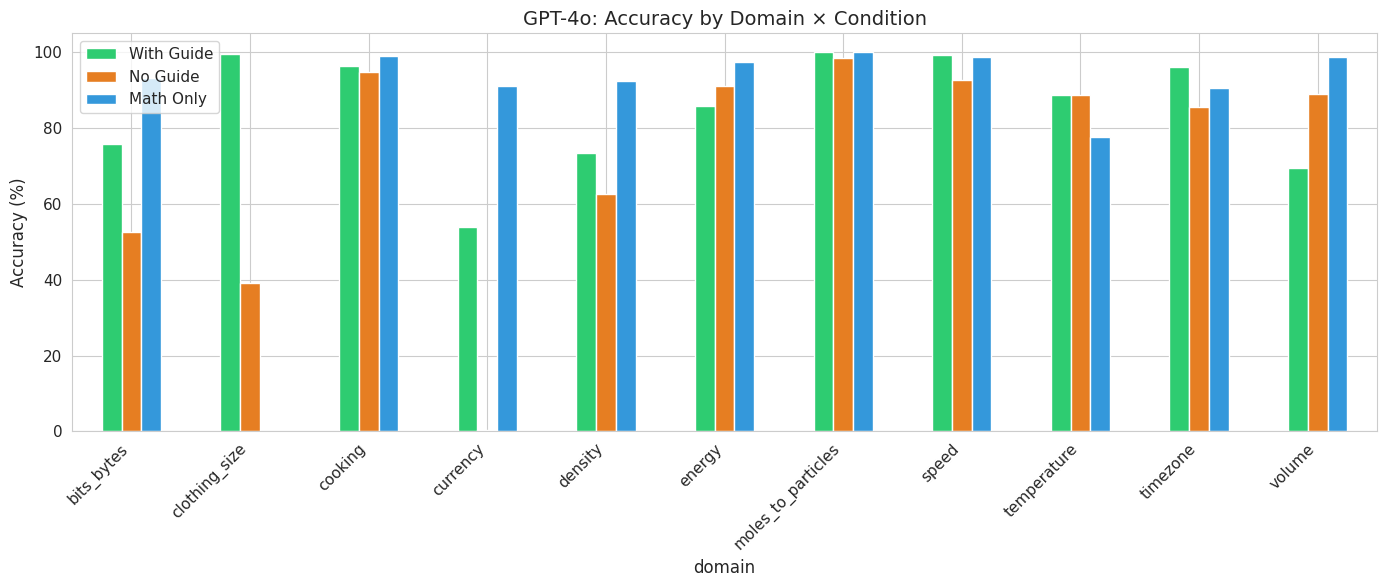


Accuracy (%) by condition — Qwen3-235B ★
condition           in_domain_with_guide  in_domain_no_guide  math_only  math−noguide  guide−noguide
domain                                                                                              
bits_bytes                         100.0                92.2      100.0           7.8            7.8
clothing_size                       99.3                 7.7        NaN           NaN           91.6
cooking                             96.0                93.5      100.0           6.5            2.5
currency                            90.2                 0.0      100.0         100.0           90.2
density                             95.3                91.8      100.0           8.2            3.5
energy                              95.8                93.9      100.0           6.1            1.9
moles_to_particles                  97.5                76.0      100.0          24.0           21.5
speed                               99.3         

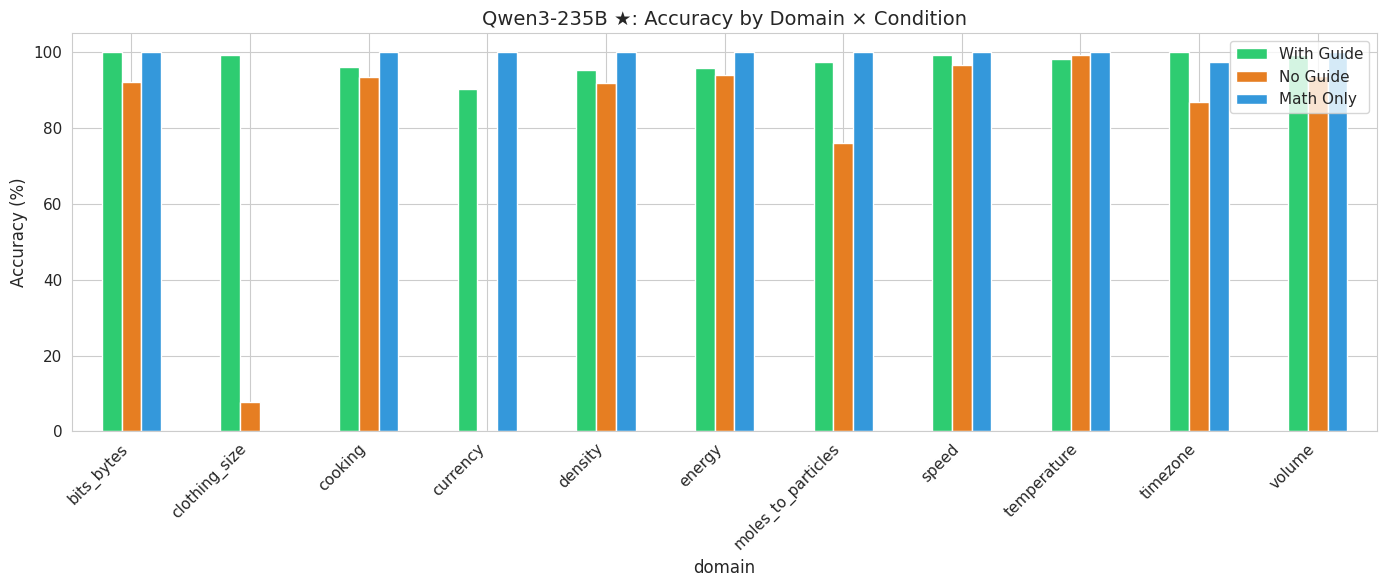

In [24]:
# Compute accuracy per model × domain × condition (no-distractor only)
mask_nodist = df['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | df['distractor'].isna()
df_nodist = df[mask_nodist].copy()

acc = df_nodist.groupby(['model', 'domain', 'condition']).agg(
    total=('loss', 'size'),
    correct=('loss', lambda x: (x == 0).sum()),
).reset_index()
acc['accuracy'] = (acc['correct'] / acc['total'] * 100).round(1)

cond_colors = [CB_PALETTE[2], CB_PALETTE[4], CB_PALETTE[0]]

for model_name in ['gpt-4o', 'qwen3-235b-thinking']:
    sub = acc[acc['model'] == model_name]
    pivot = sub.pivot(index='domain', columns='condition', values='accuracy')
    pivot = pivot.reindex(columns=['in_domain_with_guide', 'in_domain_no_guide', 'math_only'])

    if 'math_only' in pivot.columns and 'in_domain_no_guide' in pivot.columns:
        pivot['Δ math−noguide'] = (pivot['math_only'] - pivot['in_domain_no_guide']).round(1)
    if 'in_domain_with_guide' in pivot.columns and 'in_domain_no_guide' in pivot.columns:
        pivot['Δ guide−noguide'] = (pivot['in_domain_with_guide'] - pivot['in_domain_no_guide']).round(1)

    display_name = MODEL_DISPLAY.get(model_name, model_name) + REASONING_MARKER.get(model_name, '')
    print(f"\nAccuracy (%) — {display_name}")
    print(pivot.to_string())

    plot_data = pivot[['in_domain_with_guide', 'in_domain_no_guide', 'math_only']].copy()
    plot_data.columns = ['With Guide', 'No Guide', 'Math Only']

    fig, ax = plt.subplots(figsize=(PAGE_W, COL_W))
    x = np.arange(len(plot_data))
    w = 0.25
    for ci, (col, color) in enumerate(zip(plot_data.columns, cond_colors)):
        offset = (ci - 1) * w
        ax.bar(x + offset, plot_data[col], w, label=col, color=color,
               edgecolor='white', linewidth=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_data.index, rotation=40, ha='right')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 105)
    ax.set_title(f'{display_name}: Accuracy by Domain × Condition')
    ax.legend(frameon=True, edgecolor='#cccccc')
    plt.tight_layout()
    slug = model_name.replace('.', '').replace('-', '_')
    save_fig(fig, f'fig_cond_compare_{slug}')
    plt.show()

## 6. Loss Distribution Analysis

How large are the errors? Are they mostly small rounding issues or catastrophic failures?

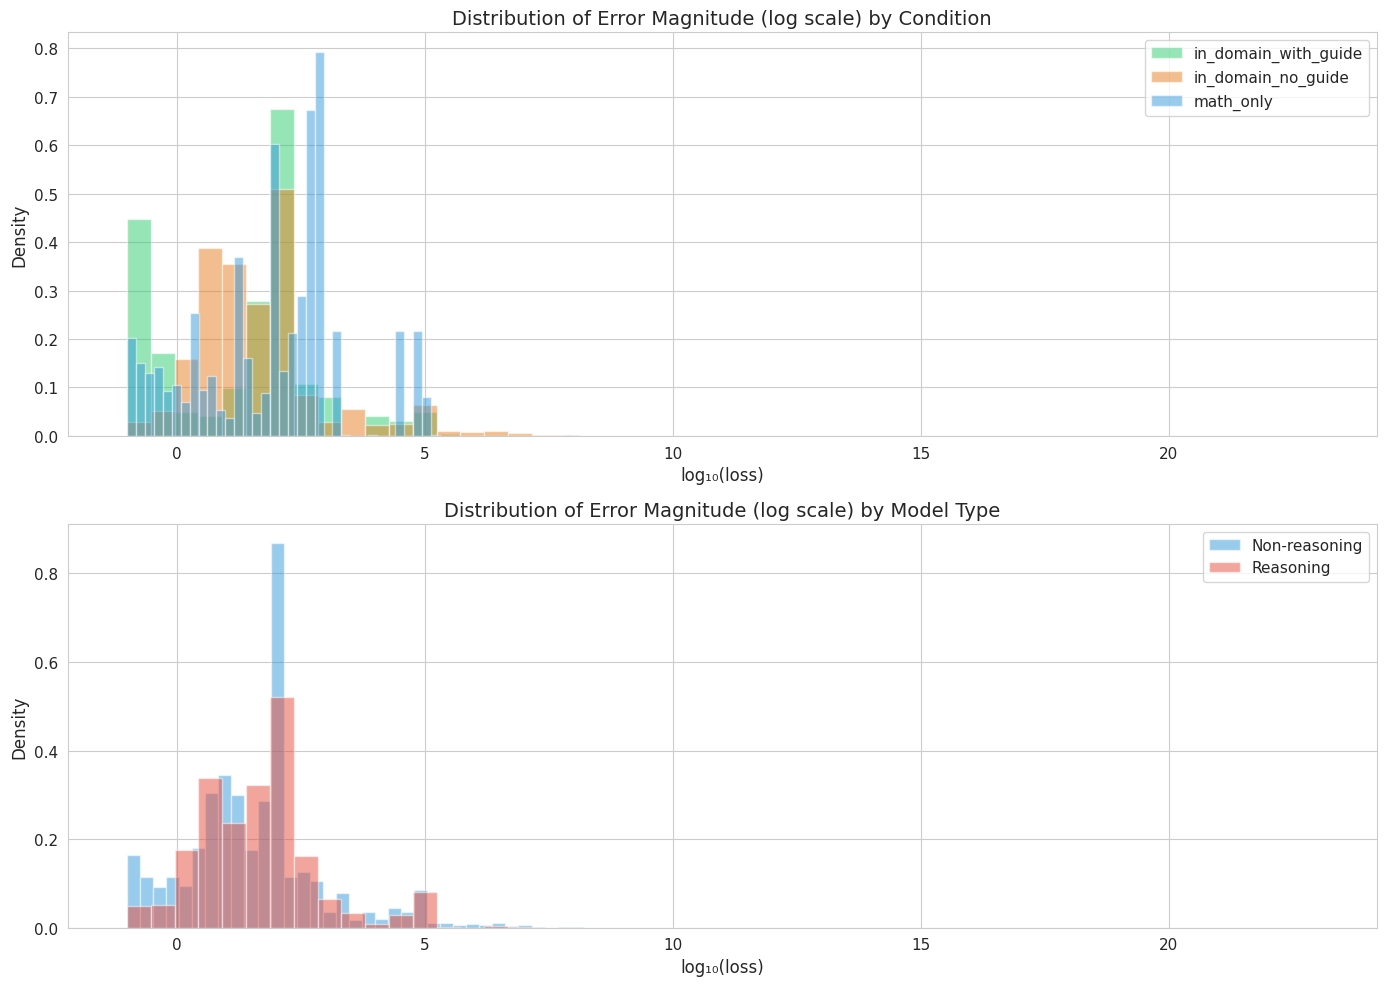


Loss statistics (wrong answers only):
  in_domain_with_guide  median=60.0  mean=8576520141929478144.0  p90=720.0  max=100085682971691647500288.0
  in_domain_no_guide  median=30.0  mean=1162916987319824128.0  p90=1574.3  max=100000019110371965009920.0
  math_only     median=131.5  mean=40090.3  p90=1682.9  max=99999900.0


In [25]:
wrong = df_nodist[df_nodist['loss'] > 0].copy()
wrong['log_loss'] = np.log10(wrong['loss'].clip(lower=1e-6))

cond_colors = [CB_PALETTE[0], CB_PALETTE[2], CB_PALETTE[4]]

fig, axes = plt.subplots(2, 1, figsize=(PAGE_W, PAGE_W / GOLDEN * 1.1))

for cond, color in zip(['in_domain_with_guide', 'in_domain_no_guide', 'math_only'], cond_colors):
    sub = wrong[wrong['condition'] == cond]
    axes[0].hist(sub['log_loss'], bins=50, alpha=0.55, label=CONDITION_DISPLAY.get(cond, cond),
                 color=color, density=True, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('log$_{10}$(loss)')
axes[0].set_ylabel('Density')
axes[0].set_title('Error Magnitude Distribution by Condition')
axes[0].legend(frameon=True, edgecolor='#cccccc')

for is_r, label, color in [(False, 'Non-Reasoning', CB_PALETTE[1]), (True, 'Reasoning', CB_PALETTE[6])]:
    sub = wrong[wrong['is_reasoning'] == is_r]
    axes[1].hist(sub['log_loss'], bins=50, alpha=0.55, label=label,
                 color=color, density=True, edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('log$_{10}$(loss)')
axes[1].set_ylabel('Density')
axes[1].set_title('Error Magnitude Distribution by Model Type')
axes[1].legend(frameon=True, edgecolor='#cccccc')

plt.tight_layout()
save_fig(fig, 'fig5_loss_distribution')
plt.show()

print("\nLoss statistics (wrong answers only):")
for cond in ['in_domain_with_guide', 'in_domain_no_guide', 'math_only']:
    sub = wrong[wrong['condition'] == cond]['loss']
    print(f"  {CONDITION_DISPLAY.get(cond, cond):16s}  median={sub.median():.1f}  mean={sub.mean():.1f}  p90={sub.quantile(0.9):.1f}  max={sub.max():.1f}")

## 7. Interactive Error Lookup

Use these helper functions to trace specific errors.

In [26]:
def lookup_errors(model_name, domain_name=None, condition=None, 
                  min_loss=0, max_results=20, number=None, error_type=None):
    """Search for specific errors in the loaded data.
    
    Args:
        model_name: Model to search
        domain_name: Optional domain filter
        condition: Optional condition filter ('in_domain_with_guide', 'in_domain_no_guide', 'math_only')
        min_loss: Minimum loss threshold
        max_results: Max rows to return
        number: Optional specific input number to search for
        error_type: Optional error type filter
    """
    sub = df[df['model'] == model_name].copy()
    if domain_name:
        sub = sub[sub['domain'] == domain_name]
    if condition:
        sub = sub[sub['condition'] == condition]
    if number is not None:
        sub = sub[sub['number'] == str(number)]
    if error_type:
        sub = sub[sub['error_type'] == error_type]
    
    sub = sub[sub['loss'] > min_loss].sort_values('loss', ascending=False).head(max_results)
    
    if len(sub) == 0:
        print("No matching errors found.")
        return pd.DataFrame()
    
    display_cols = ['domain', 'condition', 'number', 'answer', 'loss', 'error_type']
    if 'model_answer' in sub.columns:
        display_cols.append('model_answer')
    
    print(f"Found {len(sub)} errors for {model_name}:")
    return sub[display_cols]


def trace_number(number, model_name, show_response=True):
    """Trace a specific input number across all conditions and domains for a model.
    
    This shows how the model handled the same number in each (domain, condition) combination.
    """
    sub = df[(df['model'] == model_name) & (df['number'] == str(number))].copy()
    mask = sub['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | sub['distractor'].isna()
    sub = sub[mask]
    
    if len(sub) == 0:
        print(f"No data for model={model_name}, number={number}")
        return
    
    print(f"Tracing number={number} for {model_name} ({len(sub)} rows)")
    print(f"{'Domain':<35s} {'Condition':<12s} {'Gold':<18s} {'Loss':>10s} {'Error Type':<18s} {'Response (start)'}")
    print('─' * 130)
    
    # Deduplicate
    seen = set()
    for _, row in sub.sort_values(['domain', 'condition']).iterrows():
        dkey = f"{row['domain']}|{row['condition']}|{row['answer']}"
        if dkey in seen:
            continue
        seen.add(dkey)
        
        resp_short = str(row['raw_response'])[:60].replace('\n', ' ') if show_response else ''
        loss_str = f"{row['loss']:.1f}" if row['loss'] > 0 else '0'
        etype = row.get('error_type', '')
        if etype == 'correct':
            etype = '✓'
        
        print(f"{row['domain']:<35s} {row['condition']:<12s} {str(row['answer']):<18s} {loss_str:>10s} {etype:<18s} {resp_short}")


def compare_conditions(model_name, domain_name, number):
    """Side-by-side comparison of all three conditions for one specific conversion."""
    for cond in ['in_domain_with_guide', 'in_domain_no_guide', 'math_only']:
        sub = df[(df['model'] == model_name) 
                 & (df['domain'] == domain_name) 
                 & (df['condition'] == cond)
                 & (df['number'] == str(number))].copy()
        mask = sub['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | sub['distractor'].isna()
        sub = sub[mask]
        
        if len(sub) == 0:
            print(f"\n[{cond}] No data")
            continue
        
        row = sub.iloc[0]
        status = '✓ CORRECT' if row['loss'] == 0 else f'✗ WRONG (loss={row["loss"]:.1f})'
        print(f"\n[{cond}] {status}")
        print(f"  Gold: {row['answer']}")
        print(f"  Prompt: {row['prompt'][:300]}")
        print(f"  Response: {str(row['raw_response'])[:500]}")

In [27]:
# Example: Trace number 3.0 for gpt-4o
trace_number('3.0', 'gpt-4o')

Tracing number=3.0 for gpt-4o (1 rows)
Domain                              Condition    Gold                     Loss Error Type         Response (start)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
moles_to_particles                  in_domain_with_guide 1.806642228e+24             0 ✓                  1.806642228e+24


In [28]:
# Example: Compare conditions for temperature, number=75000
compare_conditions('gpt-4o', 'temperature', '75000.0')


[in_domain_with_guide] No data

[in_domain_no_guide] No data

[math_only] No data


In [29]:
# Example: Compare conditions for currency, number=1 (qwen3-235b-thinking)
compare_conditions('qwen3-235b-thinking', 'currency', '1.0')


[in_domain_with_guide] ✓ CORRECT
  Gold: 0.85
  Prompt: Convert 1 USD to EUR.

Conversion guide:
Exchange rates (relative to USD):
  GBP: 0.73
  CHF: 0.78
  EUR: 0.85
  USD: 1.0
  CAD: 1.37
  AUD: 1.44
  CNH: 6.94
  SLL: 24.48
  JPY: 155.5
  GNF: 8751.0
  UZS: 12250.0
  IDR: 16766.0
  LAK: 21495.0
  VND: 26019.92
  LBP: 85550.0
  IRR: 1189712.0

Provide 
  Response: [REASONING]
Okay, let's see. I need to convert 1 USD to EUR. The conversion guide provided has exchange rates relative to USD. So, the rate for EUR is 0.85. Wait, does that mean 1 USD equals 0.85 EUR? Let me check.

The guide says "Exchange rates (relative to USD)" and lists EUR as 0.85. So, if USD is 1.0, then 1 USD should be equal to 0.85 EUR. That makes sense because if the rate is given relative to USD, then each unit of USD converts to that amount in the other currency.

So, 1 USD * 0.85 EU

[in_domain_no_guide] ✗ WRONG (loss=238017.6)
  Gold: 0.85
  Prompt: Convert 1 USD to EUR. Provide only the numerical value.
  Re

In [30]:
# Example: Find worst decimal_shift errors for gpt-4o
lookup_errors('gpt-4o', error_type='decimal_shift', min_loss=50)

Found 20 errors for gpt-4o:


,domain,condition,number,answer,loss,error_type,model_answer
1405641,volume,in_domain_no_guide,6000,768000.1589873264,1.039900e+06,decimal_shift,7987200000.0
1405269,volume,in_domain_no_guide,800,102400.0211983102,1.015525e+06,decimal_shift,1040000000.0
1403409,volume,in_domain_no_guide,20,2560.0005299577547,1.009275e+06,decimal_shift,25840000.0
1415254,volume,in_domain_no_guide,2,8.4535,9.999007e+05,decimal_shift,84535.0575
1417796,volume,in_domain_no_guide,1000,4226.75,9.999007e+05,decimal_shift,42267528.5
1327323,currency,in_domain_no_guide,21.0,0.000432,9.687164e+05,decimal_shift,4.1863
1327324,currency,in_domain_no_guide,22.0,0.000453,9.648400e+05,decimal_shift,4.3681
1327363,currency,in_domain_no_guide,225.0,0.00463,9.598861e+05,decimal_shift,44.4444
1327362,currency,in_domain_no_guide,220.0,0.004527,9.571591e+05,decimal_shift,43.3333
1327376,currency,in_domain_no_guide,500.0,0.010288,9.545302e+05,decimal_shift,98.2143


In [31]:
# Example: Find all refusals for qwen3-235b-thinking
lookup_errors('qwen3-235b-thinking', error_type='refusal', min_loss=0)

Found 1 errors for qwen3-235b-thinking:


,domain,condition,number,answer,loss,error_type,model_answer
1955202,moles_to_particles,in_domain_no_guide,275,1.656088709e+26,99.636372,refusal,6.022e+23


## 8. Aggregate Error Summary

High-level view: error rate and dominant error type per model × domain × condition.

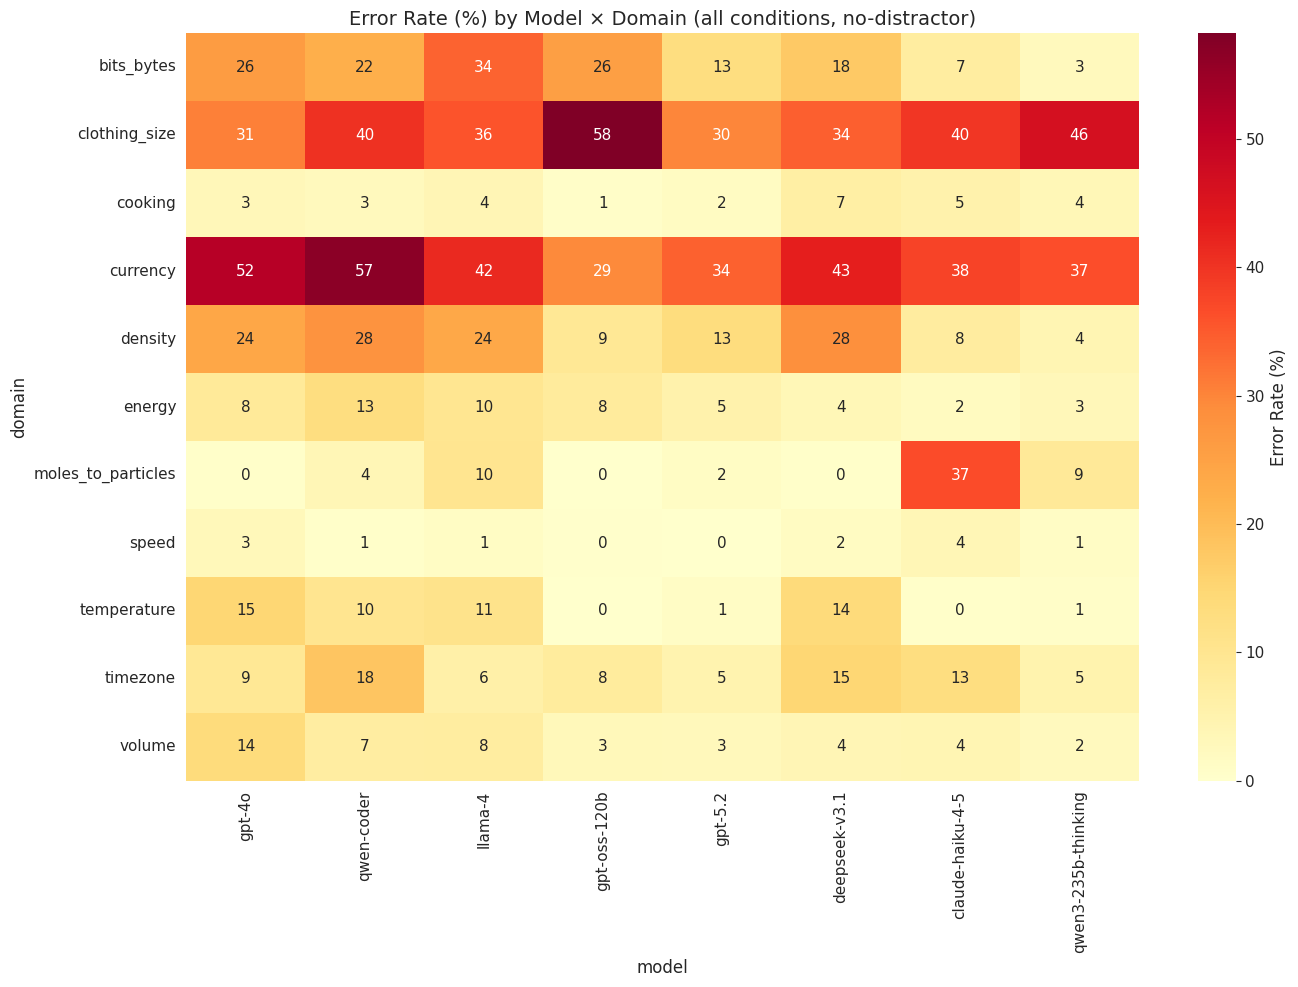

In [32]:
# Error rate heatmap: model × domain (across all conditions)
error_rate = df_nodist.groupby(['model', 'domain']).agg(
    total=('loss', 'size'),
    errors=('loss', lambda x: (x > 0).sum()),
).reset_index()
error_rate['error_pct'] = (error_rate['errors'] / error_rate['total'] * 100).round(1)

pivot_err = error_rate.pivot(index='domain', columns='model', values='error_pct')
pivot_err = pivot_err.reindex(columns=[m for m in ALL_MODELS if m in pivot_err.columns])
pivot_err.columns = [MODEL_DISPLAY.get(m, m) for m in pivot_err.columns]

fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN * 1.1))
sns.heatmap(pivot_err, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            annot_kws={'size': 7}, linewidths=0.3, linecolor='#eeeeee',
            cbar_kws={'label': 'Error Rate (%)', 'shrink': 0.8})
ax.set_title('Error Rate (%) by Model × Domain')
ax.set_ylabel('')
plt.tight_layout()
save_fig(fig, 'fig6_error_rate_heatmap')
plt.show()

In [33]:
# Dominant error type per model × domain
err_only = df_nodist[df_nodist['error_type'] != 'correct']
dominant = err_only.groupby(['model', 'domain'])['error_type'].agg(
    lambda x: x.value_counts().index[0] if len(x) > 0 else 'none'
).unstack(level='model')
dominant = dominant.reindex(columns=[m for m in ALL_MODELS if m in dominant.columns])

print("Dominant error type per model × domain:")
print(dominant.to_string())

Dominant error type per model × domain:
model                       gpt-4o       qwen-coder          llama-4    gpt-oss-120b          gpt-5.2   deepseek-v3.1 claude-haiku-4-5 qwen3-235b-thinking
domain                                                                                                                                                    
bits_bytes          moderate_error   moderate_error   moderate_error  moderate_error   moderate_error  moderate_error   moderate_error      changed_answer
clothing_size             rounding         rounding         rounding        rounding         rounding        rounding         rounding            rounding
cooking                   rounding         rounding    decimal_shift        rounding         rounding        rounding   changed_answer      changed_answer
currency            moderate_error   moderate_error   moderate_error  moderate_error   moderate_error  moderate_error   moderate_error      moderate_error
density                   roun

## 9. Distractor Impact on Errors

Do substance distractors (e.g., *"Convert 350 teaspoons of osmium to cups"*) increase errors?

Domains with distractor rows: ['cooking', 'density', 'energy', 'moles_to_particles', 'volume']

cooking (no_guide condition) — Error rate (%):
                     No Distractor  With Distractor  Delta
model                                                     
gpt-4o                         5.3              5.8    0.5
qwen-coder                     5.2             12.1    6.9
llama-4                        9.5              7.3   -2.2
gpt-oss-120b                   0.7              1.7    1.1
gpt-5.2                        4.5              7.0    2.5
deepseek-v3.1                 17.3             12.2   -5.1
claude-haiku-4-5              10.2             11.9    1.7
qwen3-235b-thinking            6.5             10.5    4.0

density (no_guide condition) — Error rate (%):
                     No Distractor  With Distractor  Delta
model                                                     
gpt-4o                        37.5             35.8   -1.7
qwen-coder                    44.0        

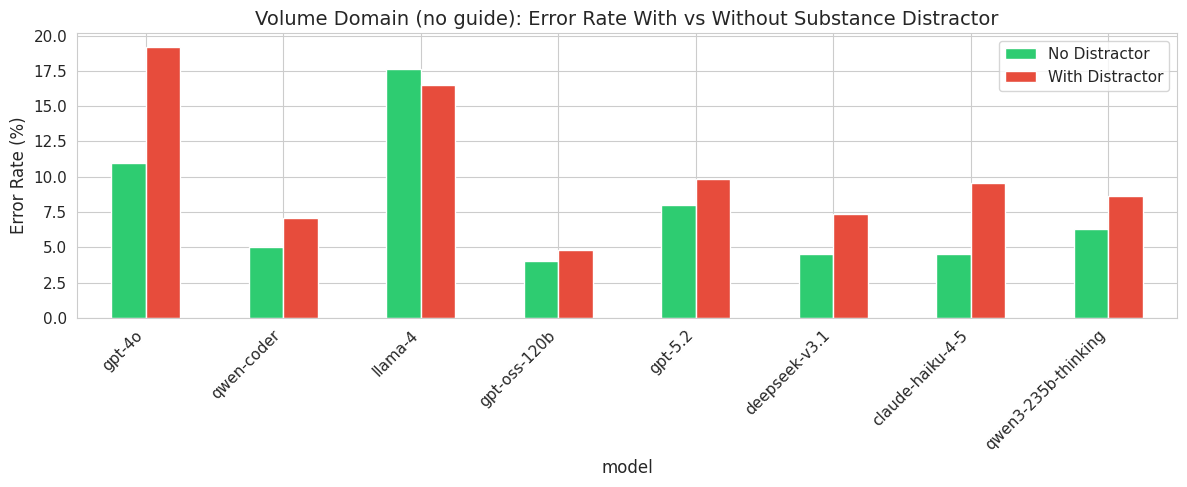

In [34]:
# Domains that have distractors: volume, cooking (and maybe others)
df['has_distractor'] = ~(
    df['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | df['distractor'].isna()
)

domains_with_distractors = df[df['has_distractor']]['domain'].unique()
print(f"Domains with distractor rows: {sorted(domains_with_distractors)}")

# Compare error rates: with vs without distractor
distractor_compare = []
for dom in sorted(domains_with_distractors):
    for m in ALL_MODELS:
        for cond in ['in_domain_with_guide', 'in_domain_no_guide']:
            sub = df[(df['domain'] == dom) & (df['model'] == m) & (df['condition'] == cond)]
            for has_d in [True, False]:
                s = sub[sub['has_distractor'] == has_d]
                if len(s) > 0:
                    distractor_compare.append({
                        'domain': dom, 'model': m, 'condition': cond,
                        'has_distractor': has_d,
                        'n': len(s),
                        'error_rate': (s['loss'] > 0).mean() * 100,
                        'mean_loss': s[s['loss'] > 0]['loss'].mean() if (s['loss'] > 0).any() else 0,
                    })

dc = pd.DataFrame(distractor_compare)
if len(dc) > 0:
    # Pivot for comparison
    for dom in sorted(domains_with_distractors)[:3]:
        sub = dc[(dc['domain'] == dom) & (dc['condition'] == 'in_domain_no_guide')]
        if len(sub) == 0:
            continue
        pv = sub.pivot(index='model', columns='has_distractor', values='error_rate')
        pv.columns = ['No Distractor', 'With Distractor']
        pv['Delta'] = pv['With Distractor'] - pv['No Distractor']
        pv = pv.reindex(index=[m for m in ALL_MODELS if m in pv.index])
        print(f"\n{dom} (no_guide condition) — Error rate (%):")
        print(pv.round(1).to_string())
    
    # Plot for volume (no_guide)
    sub = dc[(dc['domain'] == 'volume') & (dc['condition'] == 'in_domain_no_guide')]
    if len(sub) > 0:
        fig, ax = plt.subplots(figsize=(12, 5))
        pv = sub.pivot(index='model', columns='has_distractor', values='error_rate')
        pv.columns = ['No Distractor', 'With Distractor']
        pv = pv.reindex(index=[m for m in ALL_MODELS if m in pv.index])
        pv.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
        ax.set_ylabel('Error Rate (%)')
        ax.set_title('Volume Domain (no guide): Error Rate With vs Without Substance Distractor')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

## 10. Reasoning vs Non-Reasoning Error Profiles

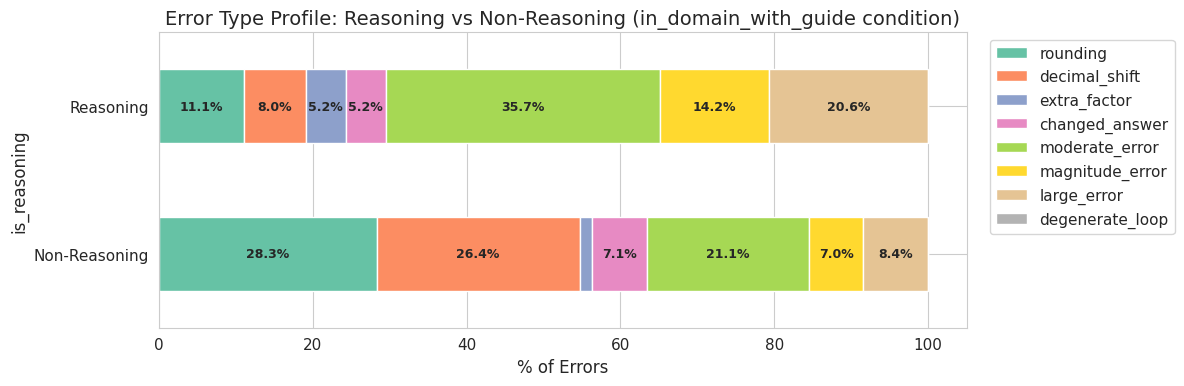

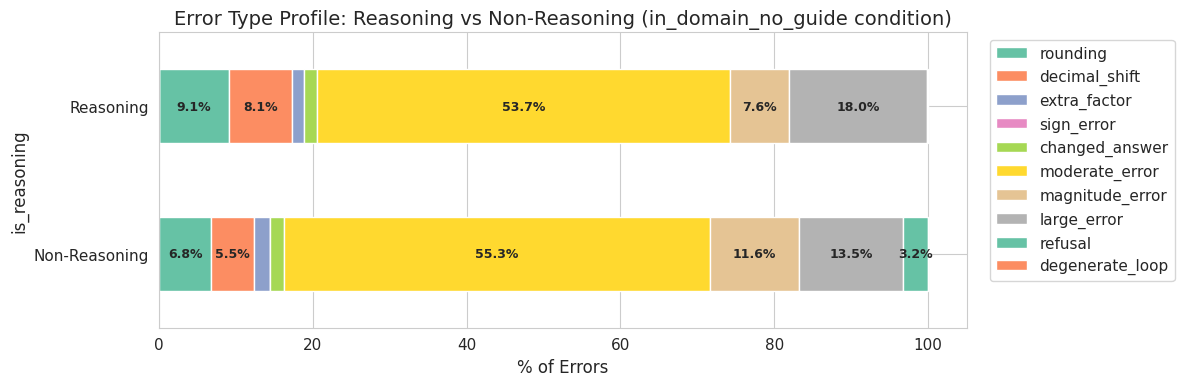

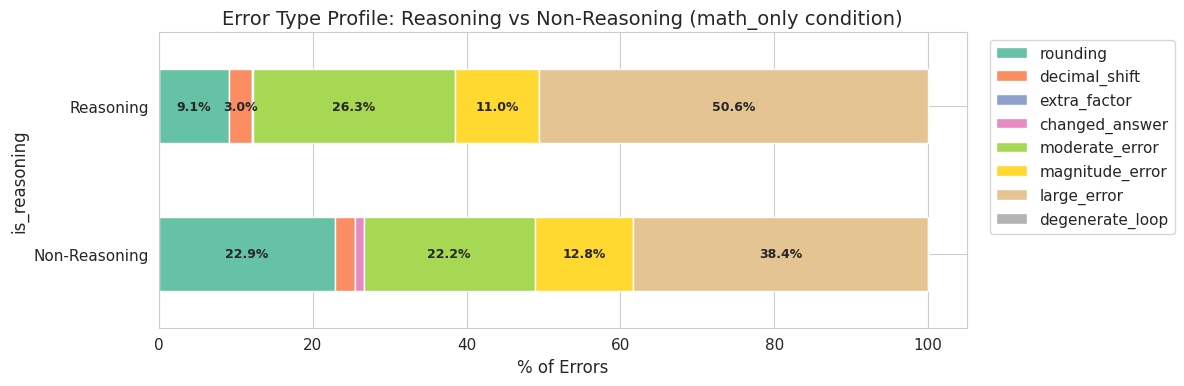

In [35]:
# Reasoning vs non-reasoning error profiles — single figure with subplots
err_nodist = df_nodist[df_nodist['error_type'] != 'correct'].copy()
cond_list = ['in_domain_with_guide', 'in_domain_no_guide', 'math_only']

fig, axes = plt.subplots(len(cond_list), 1, figsize=(PAGE_W, COL_W * 1.8), sharex=True)

for ci, cond in enumerate(cond_list):
    ax = axes[ci]
    sub = err_nodist[err_nodist['condition'] == cond]
    if len(sub) == 0:
        continue
    ct_r = pd.crosstab(sub['is_reasoning'], sub['error_type'], normalize='index') * 100
    ct_r.index = ct_r.index.map({True: 'Reasoning', False: 'Non-Reasoning'})
    ct_r = ct_r.reindex(columns=[c for c in error_order if c in ct_r.columns])

    y = np.arange(len(ct_r))
    left = np.zeros(len(ct_r))
    for col in ct_r.columns:
        vals = ct_r[col].values.astype(float)
        ax.barh(y, vals, left=left, label=col if ci == 0 else '',
                color=ERROR_COLORS[col], hatch=ERROR_HATCHES[col],
                edgecolor='white', linewidth=0.3, height=0.5)
        for j, (v, l) in enumerate(zip(vals, left)):
            if v > 4:
                ax.text(l + v / 2, j, f'{v:.0f}', ha='center', va='center',
                        fontsize=5.5, fontweight='bold',
                        color='white' if v > 12 else 'black')
        left += vals
    ax.set_yticks(y)
    ax.set_yticklabels(ct_r.index)
    ax.set_xlim(0, 100)
    ax.set_title(CONDITION_DISPLAY.get(cond, cond), fontsize=9)
    ax.invert_yaxis()

axes[-1].set_xlabel('Percentage of Errors (%)')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True,
               edgecolor='#cccccc', fancybox=False)
fig.suptitle('Reasoning vs Non-Reasoning Error Profiles', fontsize=10, y=1.02)
plt.tight_layout()
save_fig(fig, 'fig7_reasoning_vs_nonreasoning')
plt.show()

## 11. Detailed No-Guide Error Analysis

The **no_guide** condition is where models must perform conversions using only their parametric knowledge (no conversion guide provided). This section focuses exclusively on that condition to understand where and why models fail without explicit instructions.

In [36]:
ng_all = df[df['condition'] == 'in_domain_no_guide'].copy()
ng_nodist = ng_all[
    ng_all['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | ng_all['distractor'].isna()
].copy()

print(f"No-guide total rows: {len(ng_all):,}")
print(f"No-guide (no distractor): {len(ng_nodist):,}")
print(f"Models: {sorted(ng_nodist['model'].unique())}")
print(f"Domains: {sorted(ng_nodist['domain'].unique())}")

# --- 11.1 Overall accuracy by model ---
print("\n=== 11.1 No-Guide Accuracy by Model ===")
acc = ng_nodist.groupby('model').agg(
    total=('loss', 'size'),
    correct=('loss', lambda x: (x == 0).sum()),
    wrong=('loss', lambda x: (x > 0).sum()),
    parse_fail=('loss', lambda x: x.isna().sum()),
).reset_index()
acc['accuracy_pct'] = (acc['correct'] / acc['total'] * 100).round(1)
acc['error_pct'] = (acc['wrong'] / acc['total'] * 100).round(1)
acc = acc.sort_values('accuracy_pct', ascending=False)
print(acc.to_string(index=False))

No-guide total rows: 903,024
No-guide (no distractor): 183,024
Models: ['claude-haiku-4-5', 'deepseek-v3.1', 'gpt-4o', 'gpt-5.2', 'gpt-oss-120b', 'llama-4', 'qwen-coder', 'qwen3-235b-thinking']
Domains: ['bits_bytes', 'clothing_size', 'cooking', 'currency', 'density', 'energy', 'moles_to_particles', 'speed', 'temperature', 'timezone', 'volume']

=== 11.1 No-Guide Accuracy by Model ===
              model  total  correct  wrong  parse_fail  accuracy_pct  error_pct
qwen3-235b-thinking  16773    13896   2874           3          82.8       17.1
      deepseek-v3.1  16773    12484   4094         195          74.4       24.4
            gpt-5.2  27073    13666  12208        1199          50.5       45.1
            llama-4  27073    13508  13558           7          49.9       50.1
             gpt-4o  27073    13382  13687           4          49.4       50.6
         qwen-coder  27073    10829  16228          16          40.0       59.9
   claude-haiku-4-5  20593     7545  12926         1

### 11.2 No-Guide Accuracy by Model × Domain

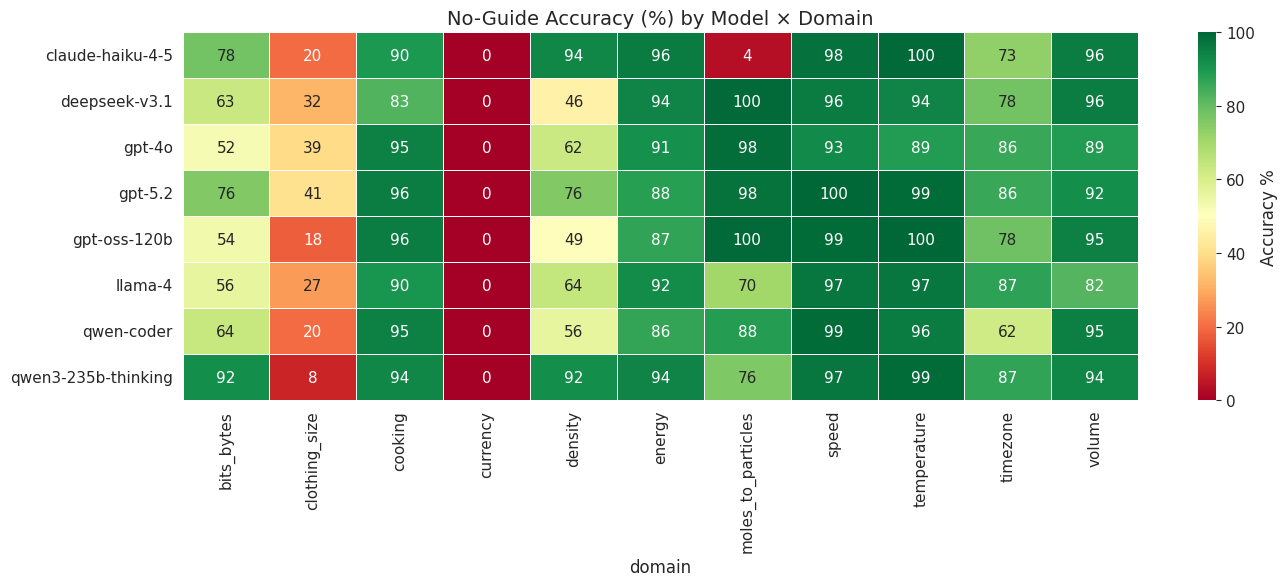

In [37]:
# Accuracy heatmap: model × domain for no_guide
ng_acc = ng_nodist.groupby(['model', 'domain']).apply(
    lambda g: (g['loss'] == 0).sum() / len(g) * 100
).unstack(fill_value=0).astype(float)
ng_acc.index = [MODEL_DISPLAY.get(m, m) + REASONING_MARKER.get(m, '') for m in ng_acc.index]

fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN / 1.5))
sns.heatmap(ng_acc, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.3, linecolor='#eeeeee', ax=ax,
            annot_kws={'size': 7}, cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8})
ax.set_title('No-Guide Accuracy (%) by Model × Domain')
ax.set_ylabel('')
plt.tight_layout()
save_fig(fig, 'fig8_noguide_accuracy_heatmap')
plt.show()

### 11.3 No-Guide Error Type Distribution by Model

Total no-guide errors (no distractor): 85,992

error_type           rounding  decimal_shift  extra_factor  sign_error  changed_answer  moderate_error  magnitude_error  large_error  refusal  degenerate_loop
model                                                                                                                                                         
claude-haiku-4-5          706            275           153           5             883            6956              909          984     2055                0
deepseek-v3.1             405            267            45           0               0            1746              291         1319       21                0
gpt-4o                    934           1557           291           0               0            7226             1627         2052        0                0
gpt-5.2                  1100           1237           243           0               0            6664             1124         1840        0                0

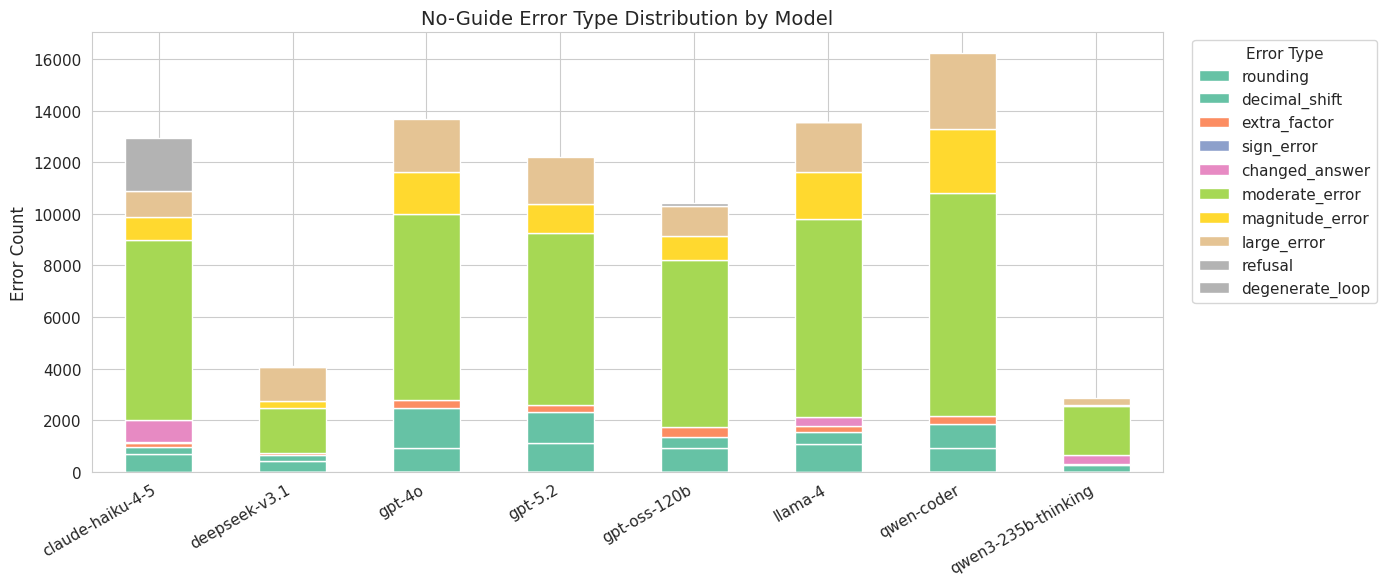

In [38]:
ng_errors = ng_nodist[ng_nodist['error_type'] != 'correct'].copy()
print(f"Total no-guide errors (no distractor): {len(ng_errors):,}\n")

etype_order = ['rounding', 'decimal_shift', 'extra_factor', 'sign_error', 'changed_answer',
               'moderate_error', 'magnitude_error', 'large_error', 'refusal', 'degenerate_loop']
ct = pd.crosstab(ng_errors['model'], ng_errors['error_type'])
ct = ct.reindex(columns=[c for c in etype_order if c in ct.columns], fill_value=0)

fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN / 1.8))
labels = [MODEL_DISPLAY.get(m, m) + REASONING_MARKER.get(m, '') for m in ct.index]
x = np.arange(len(ct))
bottom = np.zeros(len(ct))
for col in ct.columns:
    vals = ct[col].values.astype(float)
    ax.bar(x, vals, bottom=bottom, label=col, color=ERROR_COLORS.get(col, '#999'),
           hatch=ERROR_HATCHES.get(col, ''), edgecolor='white', linewidth=0.3, width=0.7)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Error Count')
ax.set_title('No-Guide Error Type Distribution by Model')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True,
          edgecolor='#cccccc', fancybox=False)
plt.tight_layout()
save_fig(fig, 'fig9_noguide_error_by_model')
plt.show()

# Publication table
ct_ng_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_ng_pct.index = [MODEL_DISPLAY.get(m, m) + REASONING_MARKER.get(m, '') for m in ct_ng_pct.index]
ct_ng_pct['N'] = ct.sum(axis=1).values
ct_ng_pct.index.name = 'Model'
print("\nTABLE: No-Guide Error Type % by Model")
print(ct_ng_pct.round(1).to_string())
print("\n--- LaTeX ---")
print(ct_ng_pct.round(1).to_latex(caption='No-guide error type distribution (\\%) by model.',
                                   label='tab:noguide_error_by_model'))

### 11.4 No-Guide Error Type Distribution by Domain

error_type          rounding  decimal_shift  extra_factor  sign_error  changed_answer  moderate_error  magnitude_error  large_error  refusal  degenerate_loop
domain                                                                                                                                                       
currency                3605           4261          1551           5             885           39540             8750         4898     1749                0
timezone                   0              0             0           0               0            6245                0         7577      440                0
clothing_size           1504              0             0           0             117               0                0            0        0                0
bits_bytes                88             83             4           0              73            1204              139            0        0                0
density                  323            528         

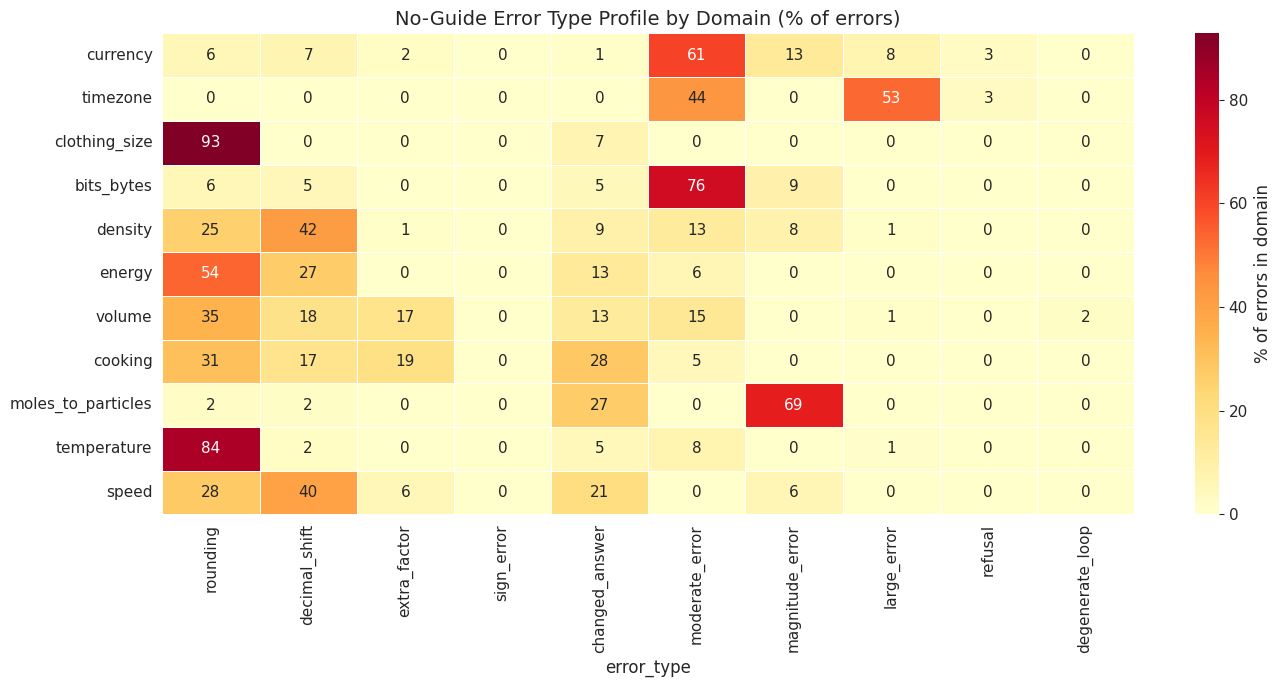

In [39]:
# Crosstab: domain × error_type
ct_dom = pd.crosstab(ng_errors['domain'], ng_errors['error_type'])
ct_dom = ct_dom.reindex(columns=[c for c in etype_order if c in ct_dom.columns], fill_value=0)
ct_dom = ct_dom.loc[ct_dom.sum(axis=1).sort_values(ascending=False).index]

ct_dom_pct = ct_dom.div(ct_dom.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN / 1.3))
sns.heatmap(ct_dom_pct, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.3, linecolor='#eeeeee', ax=ax,
            annot_kws={'size': 7}, cbar_kws={'label': '% of Errors', 'shrink': 0.8})
ax.set_title('No-Guide Error Type Profile by Domain')
ax.set_ylabel('')
plt.tight_layout()
save_fig(fig, 'fig10_noguide_error_domain_heatmap')
plt.show()

# Publication table
ct_dom_pct['N'] = ct_dom.sum(axis=1)
ct_dom_pct.index.name = 'Domain'
print("\nTABLE: No-Guide Error Type % by Domain")
print(ct_dom_pct.round(1).to_string())
print("\n--- LaTeX ---")
print(ct_dom_pct.round(1).to_latex(caption='No-guide error type profile (\\%) by domain.',
                                    label='tab:noguide_error_by_domain'))

### 11.5 No-Guide Loss Severity by Model × Domain

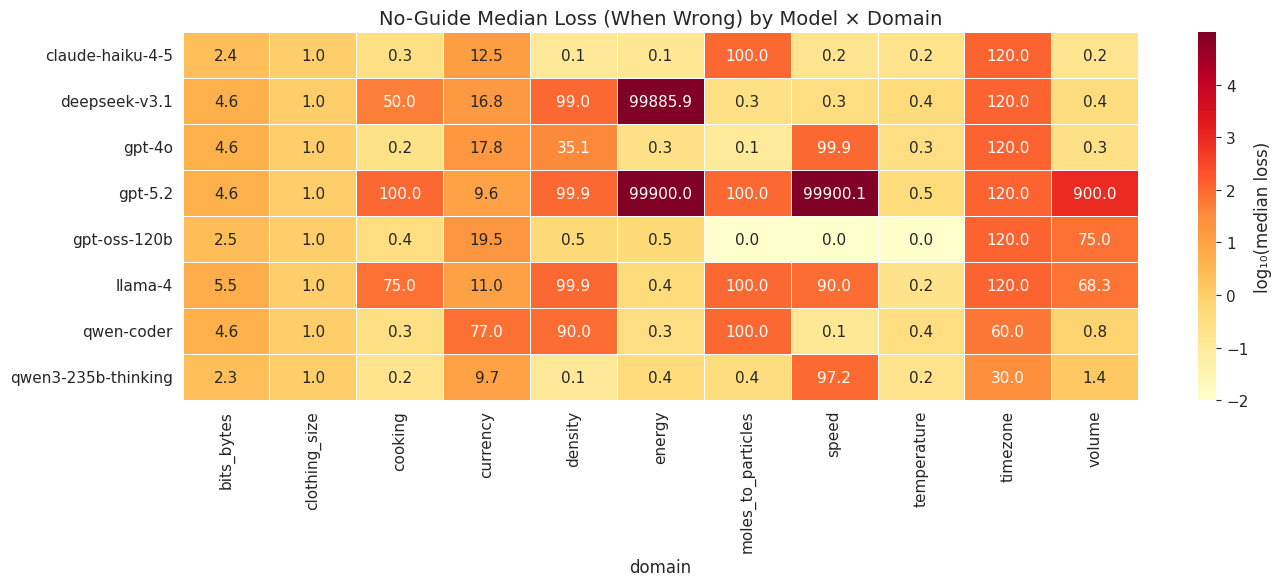


Median loss (when wrong):
domain               bits_bytes  clothing_size  cooking  currency  density    energy  moles_to_particles     speed  temperature  timezone  volume
model                                                                                                                                            
claude-haiku-4-5           2.36            1.0     0.30     12.47     0.12      0.14              100.00      0.16         0.18     120.0    0.16
deepseek-v3.1              4.63            1.0    50.00     16.78    99.01  99885.95                0.27      0.34         0.42     120.0    0.37
gpt-4o                     4.64            1.0     0.23     17.81    35.11      0.26                0.11     99.90         0.34     120.0    0.25
gpt-5.2                    4.63            1.0   100.00      9.60    99.90  99900.00              100.00  99900.08         0.46     120.0  900.00
gpt-oss-120b               2.50            1.0     0.35     19.49     0.50      0.50             

In [40]:
# Median loss (when wrong) by model × domain
ng_wrong = ng_nodist[ng_nodist['loss'] > 0].copy()
median_loss = ng_wrong.groupby(['model', 'domain'])['loss'].median().unstack(fill_value=0)
median_loss.index = [MODEL_DISPLAY.get(m, m) + REASONING_MARKER.get(m, '') for m in median_loss.index]

fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN / 1.5))
sns.heatmap(np.log10(median_loss.clip(lower=0.01)), annot=median_loss.round(1).astype(str).values,
            fmt='', cmap='YlOrRd', linewidths=0.3, linecolor='#eeeeee', ax=ax,
            annot_kws={'size': 6}, cbar_kws={'label': 'log$_{10}$(median loss)', 'shrink': 0.8})
ax.set_title('No-Guide Median Loss (When Wrong) by Model × Domain')
ax.set_ylabel('')
plt.tight_layout()
save_fig(fig, 'fig11_noguide_median_loss_heatmap')
plt.show()

print("\nMedian loss (when wrong):")
print(median_loss.round(2).to_string())


NON-REASONING models — 66,816 errors / 122,405 total (54.6% error rate)
error_type
moderate_error     36982
large_error         9036
magnitude_error     7775
rounding            4540
decimal_shift       3678
refusal             2168
extra_factor        1413
changed_answer      1213
degenerate_loop        6
sign_error             5

REASONING models — 19,176 errors / 60,619 total (31.6% error rate)
error_type
moderate_error     10295
large_error         3455
rounding            1752
decimal_shift       1559
magnitude_error     1457
changed_answer       339
extra_factor         298
refusal               21


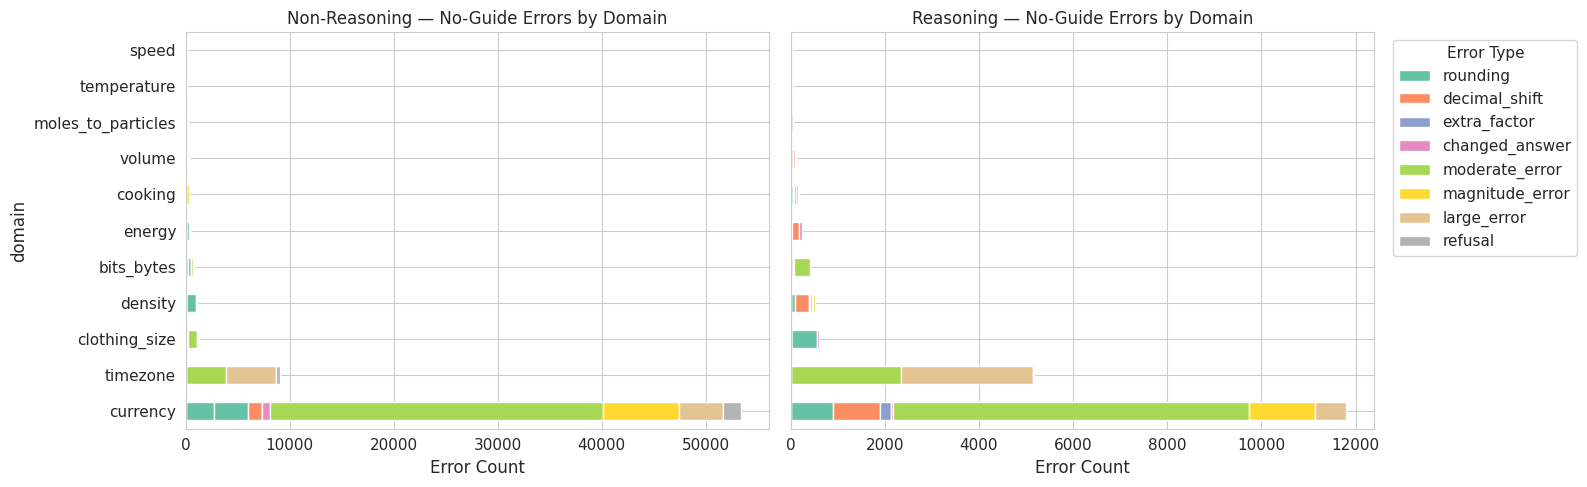

In [41]:
REASONING = {'gpt-5.2', 'deepseek-v3.1', 'qwen3-235b-thinking', 'qwen3-next-thinking', 'deepseek-r1'}
ng_nodist['model_type'] = ng_nodist['model'].apply(lambda m: 'reasoning' if m in REASONING else 'non-reasoning')

# Error type proportions split by model type
for mt in ['non-reasoning', 'reasoning']:
    sub = ng_nodist[ng_nodist['model_type'] == mt]
    sub_err = sub[sub['error_type'] != 'correct']
    total = len(sub)
    n_err = len(sub_err)
    print(f"\n{'='*50}")
    print(f"{mt.upper()} models — {n_err:,} errors / {total:,} total ({n_err/total*100:.1f}% error rate)")
    print(sub_err['error_type'].value_counts().to_string())

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, mt in zip(axes, ['non-reasoning', 'reasoning']):
    sub_err = ng_errors[ng_errors['model'].apply(lambda m: (m in REASONING) == (mt == 'reasoning'))]
    ct_mt = pd.crosstab(sub_err['domain'], sub_err['error_type'])
    ct_mt = ct_mt.reindex(columns=[c for c in etype_order if c in ct_mt.columns], fill_value=0)
    ct_mt = ct_mt.loc[ct_mt.sum(axis=1).sort_values(ascending=False).index]
    ct_mt.plot(kind='barh', stacked=True, ax=ax, colormap='Set2', legend=(mt == 'reasoning'))
    ax.set_title(f'{mt.title()} — No-Guide Errors by Domain', fontsize=12)
    ax.set_xlabel('Error Count')
    if mt == 'reasoning':
        ax.legend(title='Error Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 11.7 No-Guide: Hardest Conversions (Highest Error Rate)

In [42]:
# Per-model breakdown of worst domains (highest error rate, min 50 samples)
print("=== Top 5 Worst Domains per Model (No-Guide, no distractor) ===\n")
for model in sorted(ng_nodist['model'].unique()):
    sub = ng_nodist[ng_nodist['model'] == model]
    dom_stats = sub.groupby('domain').agg(
        n=('loss', 'size'),
        n_wrong=('loss', lambda x: (x > 0).sum()),
        mean_loss=('loss', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
        dominant_error=('error_type', lambda x: x[x != 'correct'].mode().iloc[0] if (x != 'correct').any() else '-'),
    ).reset_index()
    dom_stats['error_pct'] = (dom_stats['n_wrong'] / dom_stats['n'] * 100).round(1)
    dom_stats = dom_stats[dom_stats['n'] >= 50].sort_values('error_pct', ascending=False)
    print(f"--- {model} ---")
    print(dom_stats[['domain','n','n_wrong','error_pct','mean_loss','dominant_error']].head(5).to_string(index=False))
    print()

=== Top 5 Worst Domains per Model (No-Guide, no distractor) ===

--- claude-haiku-4-5 ---
            domain     n  n_wrong  error_pct    mean_loss  dominant_error
          currency 11200    11046       98.6 74339.776947  moderate_error
moles_to_particles   200      193       96.5   100.000000 magnitude_error
     clothing_size   273      216       79.1     1.000000        rounding
          timezone  4320     1157       26.8   208.573898     large_error
        bits_bytes   600      132       22.0     3.300805  moderate_error

--- deepseek-v3.1 ---
       domain     n  n_wrong  error_pct     mean_loss dominant_error
     currency   900      900      100.0   4796.327182 moderate_error
clothing_size   273      187       68.5      1.000000       rounding
      density   600      327       54.5 611998.339916  decimal_shift
   bits_bytes   600      222       37.0    455.081180 moderate_error
     timezone 10800     2203       20.4    198.168407    large_error

--- gpt-4o ---
       domain

In [43]:
ng_nodist.columns

Index(['domain', 'distractor', 'prompt', 'number', 'answer', 'difficulty',
       'raw_response', 'model_answer', 'loss', 'reasoning_tokens',
       'call_seconds', 'model', 'condition', 'frequency', 'frequency_level',
       'is_reasoning', 'display_name', 'is_correct', 'num_decimals',
       'num_input_decimals', 'frequency_difficulty', 'error_type',
       'has_distractor', 'model_type'],
      dtype='object')

### 11.8 No-Guide: Difficulty Effect (Easy vs Hard Numbers)

No-Guide Accuracy by Difficulty:

frequency_difficulty  easy  hard
model                           
claude-haiku-4-5      25.5  37.5
deepseek-v3.1         69.2  74.6
gpt-4o                25.9  50.8
gpt-5.2               27.3  51.8
gpt-oss-120b          25.4  37.3
llama-4               24.4  51.4
qwen-coder            24.4  40.9
qwen3-235b-thinking   72.8  83.2


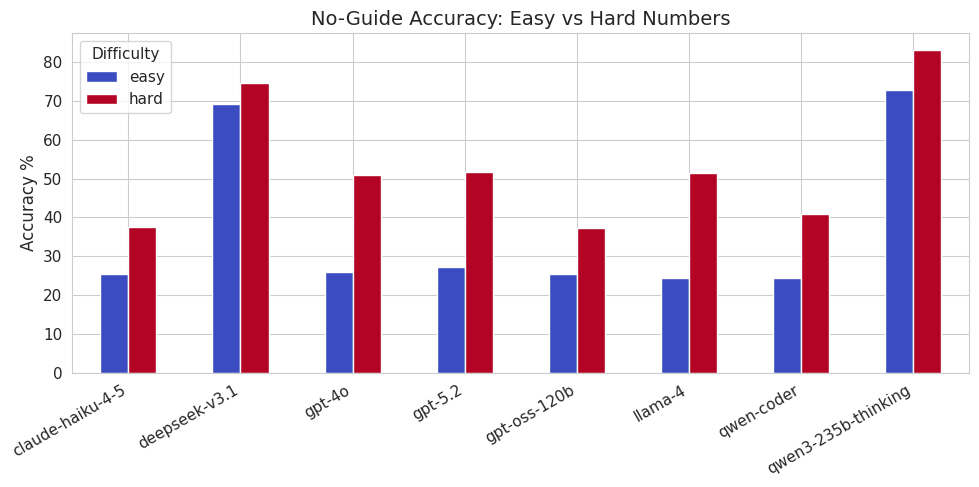


No-Guide Accuracy by Domain × Difficulty:

frequency_difficulty  easy  hard
domain                          
bits_bytes            65.7  66.9
clothing_size         24.5  25.6
cooking               88.4  92.5
currency               0.5   0.2
density               72.7  66.8
energy                88.1  91.3
moles_to_particles    70.1  80.1
speed                 96.5  97.3
temperature           97.0  96.6
timezone               0.0  80.2
volume                91.4  92.3


In [44]:
# Compare error rates for easy vs hard numbers (if difficulty column exists)
if 'difficulty' in ng_nodist.columns:
    diff_stats = ng_nodist.groupby(['model', 'frequency_difficulty']).agg(
        n=('loss', 'size'),
        correct=('loss', lambda x: (x == 0).sum()),
    ).reset_index()
    diff_stats['accuracy_pct'] = (diff_stats['correct'] / diff_stats['n'] * 100).round(1)

    pivot = diff_stats.pivot(index='model', columns='frequency_difficulty', values='accuracy_pct').fillna(0)
    print("No-Guide Accuracy by Difficulty:\n")
    print(pivot.to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind='bar', ax=ax, colormap='coolwarm')
    ax.set_title('No-Guide Accuracy: Easy vs Hard Numbers', fontsize=14)
    ax.set_ylabel('Accuracy %')
    ax.set_xlabel('')
    ax.legend(title='Difficulty')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    # Breakdown by domain too
    diff_dom = ng_nodist.groupby(['domain', 'frequency_difficulty']).agg(
        n=('loss', 'size'),
        correct=('loss', lambda x: (x == 0).sum()),
    ).reset_index()
    diff_dom['accuracy_pct'] = (diff_dom['correct'] / diff_dom['n'] * 100).round(1)
    pivot_dom = diff_dom.pivot(index='domain', columns='frequency_difficulty', values='accuracy_pct').fillna(0)
    print("\nNo-Guide Accuracy by Domain × Difficulty:\n")
    print(pivot_dom.to_string())
else:
    print("No 'difficulty' column found — skipping difficulty analysis.")

### 11.9 No-Guide: Refusal Analysis

Which models refuse to answer, and in which domains?

In [45]:
refusals = ng_errors[ng_errors['error_type'] == 'refusal']
print(f"Total refusals in no-guide: {len(refusals):,}\n")

if len(refusals) > 0:
    ref_ct = pd.crosstab(refusals['model'], refusals['domain'])
    ref_ct['TOTAL'] = ref_ct.sum(axis=1)
    ref_ct = ref_ct.sort_values('TOTAL', ascending=False)
    print(ref_ct.to_string())

    # Sample refusal responses
    print("\n\n=== Sample Refusal Responses ===")
    for model in refusals['model'].value_counts().head(3).index:
        sub = refusals[refusals['model'] == model].sample(min(3, len(refusals[refusals['model'] == model])), random_state=42)
        for _, r in sub.iterrows():
            raw = str(r.get('raw_response', ''))[:300]
            print(f"\n[{model} | {r['domain']}] number={r['number']}, gold={r['answer']}")
            print(f"  {raw}")
else:
    print("No refusals found.")

Total refusals in no-guide: 2,189

domain            currency  timezone  TOTAL
model                                      
claude-haiku-4-5      1636       419   2055
gpt-oss-120b           112         0    112
deepseek-v3.1            0        21     21
llama-4                  1         0      1


=== Sample Refusal Responses ===

[claude-haiku-4-5 | currency] number=225, gold=30589.09838875557
  [REASONING]
I need to convert 225 GNF (Guinean Francs) to IRR (Iranian Rials).

To do this, I need to know the current exchange rates for both currencies relative to a common reference (like USD) or directly between each other.

However, I should note that I don't have access to real-time exchange r

[claude-haiku-4-5 | currency] number=550, gold=7648.645236703683
  [REASONING]
I need to convert 550 Lebanese Pounds (LBP) to Iranian Rial (IRR).

To do this, I need to know the current exchange rate between LBP and IRR. However, I don't have access to real-time exchange rates, and these rates f